In [23]:
import pandas as pd

# from Clustering_and_QC import data_type
from utils import *
import matplotlib.ticker as ticker
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

import seaborn as sns
from matplotlib.lines import Line2D
import umap
import matplotlib.ticker as ticker
import matplotlib.lines as mlines
import matplotlib.ticker as ticker
from scipy import stats
import matplotlib.ticker as ticker
import matplotlib.ticker as ticker
from scipy import stats


df = pd.read_csv("Experiment/3_hTERT_HME1_mutants_comparison/Data/Processed/Mutant_cell_lines_test.tsv", sep="\t")
df

,protein_Id,protein_name,description,Peptide_Sequence,Modified_Sequence,site_start,site_end,Peptide_Length,Charges,Assigned_Modifications,...,WT_log2:FC_EGF_10,WT_log2:FC_EGF_25,BRAFS151A_log2:FC_EGF_starve,BRAFS151A_log2:FC_EGF_2,BRAFS151A_log2:FC_EGF_10,BRAFS151A_log2:FC_EGF_25,GAB1Y259A_log2:FC_EGF_starve,GAB1Y259A_log2:FC_EGF_2,GAB1Y259A_log2:FC_EGF_10,GAB1Y259A_log2:FC_EGF_25
0,P0CG40,SP9,Transcription factor Sp9,AAAAAAAAAAAAAAAASAGGKEAASGPNDS,AAAAAAAAAAAAAAAASAGGKEAAS[79.9663]GPNDS[79.9663],455,484,30,2,"25S(79.9663),30S(79.9663)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,P0CG40,SP9,Transcription factor Sp9,AAAAAAAAAAAAAAAASAGGK,AAAAAAAAAAAAAAAAS[79.9663]AGGK,455,475,21,2,17S(79.9663),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,P0CG40,SP9,Transcription factor Sp9,AAAAAAAAAAAAAAAASAGGKEAASGPNDS,AAAAAAAAAAAAAAAAS[79.9663]AGGKEAAS[79.9663]GPNDS,455,484,30,2,"17S(79.9663),25S(79.9663)",...,NaN,NaN,0.0,NaN,1.888218,NaN,0.0,2.985974,NaN,2.937885
3,Q8WXD9,CASKIN1,Caskin-1,AAAAAAAAAAAPPAPPEGASPGDSARQK,AAAAAAAAAAAPPAPPEGASPGDSARQK,1345,1372,28,2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Q8WXD9,CASKIN1,Caskin-1,AAAAAAAAAAAPPAPPEGASPGDSAR,AAAAAAAAAAAPPAPPEGAS[79.9663]PGDS[79.9663]AR,1345,1370,26,2,"20S(79.9663),24S(79.9663)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175084,P55735,SEC13,Protein SEC13 homolog,VSVINTVDTSHEDMIHDAQMDYYGTR,n[42.0106]VSVINTVDTSHEDM[15.9949]IHDAQMDYYGTR,2,27,26,3,"N-term(42.0106),14M(15.9949)",...,0.444736,0.413445,0.0,-1.338201,-1.002712,-1.289534,0.0,-0.961074,-0.582581,-0.980391
175085,P55735,SEC13,Protein SEC13 homolog,VSVINTVDTSHEDMIHDAQMDYYGTR,n[42.0106]VSVINTVDTSHEDM[15.9949]IHDAQM[15.994...,2,27,26,3,"N-term(42.0106),14M(15.9949),20M(15.9949)",...,NaN,NaN,0.0,0.170052,NaN,NaN,0.0,0.063073,0.151763,-0.751698
175086,rev_Q17R98,rev_ZNF827,Zinc finger protein 827,WQGSNLGGTPVTHCK,n[42.0106]WQGSNLGGTPVTHC[57.0215]K,2,16,15,2,"N-term(42.0106),14C(57.0215)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
175087,Q9NRJ4,TULP4,Tubby-related protein 4,YAAVEHGPVLCSDSNILCLSWK,n[42.0106]YAAVEHGPVLC[57.0215]S[79.9663]DSNILC...,2,23,22,2,"N-term(42.0106),11C(57.0215),12S(79.9663),18C(...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Filtering data

In [24]:
# Remove rows without PTM
df_filtered = df[df.Assigned_Modifications_clean.notna()]
print(f"Original size: {df.shape}")

# Drop rows where site is not detected in the starvation control
df_filtered = df_filtered[df_filtered["WT_raw:abs_EGF_starve_r1"] != 0]
df_filtered = df_filtered[df_filtered["BRAFS151A_raw:abs_EGF_starve_r1"] != 0]
df_filtered = df_filtered[df_filtered["GAB1Y259A_raw:abs_EGF_starve_r1"] != 0]

raw_columns = [element for element in df.columns if 'raw' in element]

print(f"Dataframe after removing sites with no starve detected: {df_filtered.shape}")
replicates = [element for element in raw_columns if "starve" not in element]
# print(f"Raw columns of time points replicates: {replicates}")

replicates = list(set([element.replace("_r1", "").replace("_r2", "") for element in replicates]))

suffixes = ["_r1", "_r2"]

# Drop rows if the phosphosite was not detected in the 2 replicates for any time point and any condition
for condition in replicates:
    mask = (
        (df_filtered[f"{condition}{suffixes[0]}"] == 0) &
        (df_filtered[f"{condition}{suffixes[1]}"] == 0)
    )
    df_filtered = df_filtered.drop(df_filtered[mask].index)

print(f"Dataframe after removing sites where a site is missing in the two replivates: {df_filtered.shape}")

df_filtered = filter_dynamics_extremes_mutants(df = df_filtered,
                                       data_type="log2:FC",
                                       threshold=0.5,
                                       exclude_full = False,
                                       conditions = ["_EGF_"], #, "_INS_", "_EGFnINS_"],
                                       cell_lines = ["WT", "BRAFS151A", "GAB1Y259A"],)
print(f"Dataframe after selecting log2:FC > 0.5: {df_filtered.shape}")
df_filtered["site"]

Original size: (175089, 136)
Dataframe after removing sites with no starve detected: (13474, 136)
Dataframe after removing sites where a site is missing in the two replivates: (10885, 136)
Dataframe after selecting log2:FC > 0.5: (9561, 136)


17         Q9NQS7_127_154_2_2_True_S142S148
38            Q6SPF0_151_170_1_1_False_S161
43            P19338_177_217_1_1_False_S206
44        P19338_177_217_2_1_False_S206M211
45            P19338_177_217_1_1_False_S184
                        ...                
175069          P38159_2_9_1_0_False_N-term
175071         Q9UBE0_2_21_1_0_False_N-term
175082         P55735_2_27_1_0_False_N-term
175083      P55735_2_27_2_0_False_N-termM21
175084      P55735_2_27_2_0_False_N-termM15
Name: site, Length: 9561, dtype: object

## Min/Max scaling filtered dataset

In [25]:
cell_lines = ["WT"] #, "BRAFS151A", "GAB1Y259A"]
conditions = ["_EGF_"]
data_type = "log2:FC"

column_names = df_filtered.columns.tolist()

columns_dir = {cell: {condition: {} for condition in conditions} for cell in cell_lines}
names_list = []
for cell in cell_lines:
    for condition in conditions:
        columns_dir[cell][condition] = [col for col in column_names
                                        if col.startswith(cell)
                                        and condition in col
                                        and data_type in col
                                        and "cluster" not in col
                                                    ]
        names_list = names_list + columns_dir[cell][condition]
print(names_list)

scaled_columns = [element.replace("log2:FC", "log2:scaled") for element in names_list]
print(scaled_columns)


names_list_index = ["site"] + names_list
scaled_columns_index = ["site"] + scaled_columns

subset = df_filtered[names_list].copy()
subset_scaled = pd.DataFrame(columns=scaled_columns)

for row in subset.itertuples():
    max_value = max(abs(n) for n in row[1:])  # row[0] is the index
    if max_value == 0:
        print(row)
        continue

    scaled_list = [n / max_value for n in row[1:]]
    subset_scaled.loc[row[0]] = scaled_list

# Write results back to the main DataFrame
df_filtered[scaled_columns] = subset_scaled
df_filtered

['WT_log2:FC_EGF_starve', 'WT_log2:FC_EGF_2', 'WT_log2:FC_EGF_10', 'WT_log2:FC_EGF_25']
['WT_log2:scaled_EGF_starve', 'WT_log2:scaled_EGF_2', 'WT_log2:scaled_EGF_10', 'WT_log2:scaled_EGF_25']


,protein_Id,protein_name,description,Peptide_Sequence,Modified_Sequence,site_start,site_end,Peptide_Length,Charges,Assigned_Modifications,...,BRAFS151A_log2:FC_EGF_10,BRAFS151A_log2:FC_EGF_25,GAB1Y259A_log2:FC_EGF_starve,GAB1Y259A_log2:FC_EGF_2,GAB1Y259A_log2:FC_EGF_10,GAB1Y259A_log2:FC_EGF_25,WT_log2:scaled_EGF_starve,WT_log2:scaled_EGF_2,WT_log2:scaled_EGF_10,WT_log2:scaled_EGF_25
17,Q9NQS7,INCENP,Inner centromere protein,AAAAAAAATMALAAPSSPTPESPTMLTK,AAAAAAAATMALAAPS[79.9663]SPTPES[79.9663]PTMLTK,127,154,28,"2,3","16S(79.9663),22S(79.9663)",...,0.803156,0.130157,0.0,-0.955918,0.016177,0.179395,0.0,-0.122048,-1.000000,-0.222622
38,Q6SPF0,SAMD1,Sterile alpha motif domain-containing protein 1,AAAAAATAPPSPGPAQPGPR,AAAAAATAPPS[79.9663]PGPAQPGPR,151,170,20,2,11S(79.9663),...,-0.290644,-0.431276,0.0,-0.080581,-0.012117,-0.075329,0.0,0.346018,0.829526,1.000000
43,P19338,NCL,Nucleolin,AAAAAPASEDEDDEDDEDDEDDDDDEEDDSEEEAMETTPAK,AAAAAPASEDEDDEDDEDDEDDDDDEEDDS[79.9663]EEEAMET...,177,217,41,3,30S(79.9663),...,-0.605887,-1.345394,0.0,-0.221699,-0.409022,0.028441,0.0,0.332138,0.070959,1.000000
44,P19338,NCL,Nucleolin,AAAAAPASEDEDDEDDEDDEDDDDDEEDDSEEEAMETTPAK,AAAAAPASEDEDDEDDEDDEDDDDDEEDDS[79.9663]EEEAM[1...,177,217,41,3,"30S(79.9663),35M(15.9949)",...,-0.572586,-1.853071,0.0,0.013684,-0.283210,-0.064792,0.0,1.000000,0.292133,0.978302
45,P19338,NCL,Nucleolin,AAAAAPASEDEDDEDDEDDEDDDDDEEDDSEEEAMETTPAK,AAAAAPAS[79.9663]EDEDDEDDEDDEDDDDDEEDDSEEEAMET...,177,217,41,3,8S(79.9663),...,-0.628950,-2.164579,0.0,-0.291065,-0.513799,0.083652,0.0,-0.034590,0.955708,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175069,P38159,RBMX,"RNA-binding motif protein, X chromosome",VEADRPGK,n[42.0106]VEADRPGK,2,9,8,2,N-term(42.0106),...,-1.245894,-1.831771,0.0,-0.343773,-0.090072,-0.733578,0.0,0.154527,1.000000,0.927878
175071,Q9UBE0,SAE1,SUMO-activating enzyme subunit 1,VEKEEAGGGISEEEAAQYDR,n[42.0106]VEKEEAGGGISEEEAAQYDR,2,21,20,2,N-term(42.0106),...,-0.228971,0.361825,0.0,-0.482218,-0.219705,-1.151048,0.0,-0.039091,-0.107636,1.000000
175082,P55735,SEC13,Protein SEC13 homolog,VSVINTVDTSHEDMIHDAQMDYYGTR,n[42.0106]VSVINTVDTSHEDMIHDAQMDYYGTR,2,27,26,"2,3",N-term(42.0106),...,-1.267637,-2.648075,0.0,-0.588828,0.145323,-0.892899,0.0,-1.000000,0.629357,-0.867975
175083,P55735,SEC13,Protein SEC13 homolog,VSVINTVDTSHEDMIHDAQMDYYGTR,n[42.0106]VSVINTVDTSHEDMIHDAQM[15.9949]DYYGTR,2,27,26,3,"N-term(42.0106),20M(15.9949)",...,-0.959473,-1.110505,0.0,-1.318825,-1.071842,-1.446663,0.0,-0.099192,1.000000,0.391512


In [38]:
cell_lines = ["BRAFS151A"] #, "BRAFS151A", "GAB1Y259A"]
conditions = ["_EGF_"]
data_type = "log2:FC"

column_names = df_filtered.columns.tolist()

columns_dir = {cell: {condition: {} for condition in conditions} for cell in cell_lines}
names_list = []
for cell in cell_lines:
    for condition in conditions:
        columns_dir[cell][condition] = [col for col in column_names
                                        if col.startswith(cell)
                                        and condition in col
                                        and data_type in col
                                        and "cluster" not in col
                                                    ]
        names_list = names_list + columns_dir[cell][condition]
print(names_list)

scaled_columns = [element.replace("log2:FC", "log2:scaled") for element in names_list]
print(scaled_columns)


names_list_index = ["site"] + names_list
scaled_columns_index = ["site"] + scaled_columns

subset = df_filtered[names_list].copy()
subset_scaled = pd.DataFrame(columns=scaled_columns)

for row in subset.itertuples():
    max_value = max(abs(n) for n in row[1:])  # row[0] is the index
    if max_value == 0:
        print(row)
        continue

    scaled_list = [n / max_value for n in row[1:]]
    subset_scaled.loc[row[0]] = scaled_list

# Write results back to the main DataFrame
df_filtered[scaled_columns] = subset_scaled
df_filtered

['BRAFS151A_log2:FC_EGF_starve', 'BRAFS151A_log2:FC_EGF_2', 'BRAFS151A_log2:FC_EGF_10', 'BRAFS151A_log2:FC_EGF_25']
['BRAFS151A_log2:scaled_EGF_starve', 'BRAFS151A_log2:scaled_EGF_2', 'BRAFS151A_log2:scaled_EGF_10', 'BRAFS151A_log2:scaled_EGF_25']


,protein_Id,protein_name,description,Peptide_Sequence,Modified_Sequence,site_start,site_end,Peptide_Length,Charges,Assigned_Modifications,...,GAB1Y259A_log2:FC_EGF_25,WT_log2:scaled_EGF_starve,WT_log2:scaled_EGF_2,WT_log2:scaled_EGF_10,WT_log2:scaled_EGF_25,WT_KMeans_25_clusters_log2:FC,BRAFS151A_log2:scaled_EGF_starve,BRAFS151A_log2:scaled_EGF_2,BRAFS151A_log2:scaled_EGF_10,BRAFS151A_log2:scaled_EGF_25
17,Q9NQS7,INCENP,Inner centromere protein,AAAAAAAATMALAAPSSPTPESPTMLTK,AAAAAAAATMALAAPS[79.9663]SPTPES[79.9663]PTMLTK,127,154,28,"2,3","16S(79.9663),22S(79.9663)",...,0.179395,0.0,-0.122048,-1.000000,-0.222622,2,0.0,1.000000,0.904127,0.146520
38,Q6SPF0,SAMD1,Sterile alpha motif domain-containing protein 1,AAAAAATAPPSPGPAQPGPR,AAAAAATAPPS[79.9663]PGPAQPGPR,151,170,20,2,11S(79.9663),...,-0.075329,0.0,0.346018,0.829526,1.000000,23,0.0,-1.000000,-0.301833,-0.447879
43,P19338,NCL,Nucleolin,AAAAAPASEDEDDEDDEDDEDDDDDEEDDSEEEAMETTPAK,AAAAAPASEDEDDEDDEDDEDDDDDEEDDS[79.9663]EEEAMET...,177,217,41,3,30S(79.9663),...,0.028441,0.0,0.332138,0.070959,1.000000,12,0.0,-1.000000,-0.235378,-0.522665
44,P19338,NCL,Nucleolin,AAAAAPASEDEDDEDDEDDEDDDDDEEDDSEEEAMETTPAK,AAAAAPASEDEDDEDDEDDEDDDDDEEDDS[79.9663]EEEAM[1...,177,217,41,3,"30S(79.9663),35M(15.9949)",...,-0.064792,0.0,1.000000,0.292133,0.978302,20,0.0,-1.000000,-0.289108,-0.935644
45,P19338,NCL,Nucleolin,AAAAAPASEDEDDEDDEDDEDDDDDEEDDSEEEAMETTPAK,AAAAAPAS[79.9663]EDEDDEDDEDDEDDDDDEEDDSEEEAMET...,177,217,41,3,8S(79.9663),...,0.083652,0.0,-0.034590,0.955708,1.000000,13,0.0,-0.960596,-0.290565,-1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175069,P38159,RBMX,"RNA-binding motif protein, X chromosome",VEADRPGK,n[42.0106]VEADRPGK,2,9,8,2,N-term(42.0106),...,-0.733578,0.0,0.154527,1.000000,0.927878,13,0.0,-0.985919,-0.680158,-1.000000
175071,Q9UBE0,SAE1,SUMO-activating enzyme subunit 1,VEKEEAGGGISEEEAAQYDR,n[42.0106]VEKEEAGGGISEEEAAQYDR,2,21,20,2,N-term(42.0106),...,-1.151048,0.0,-0.039091,-0.107636,1.000000,12,0.0,1.000000,-0.197440,0.311999
175082,P55735,SEC13,Protein SEC13 homolog,VSVINTVDTSHEDMIHDAQMDYYGTR,n[42.0106]VSVINTVDTSHEDMIHDAQMDYYGTR,2,27,26,"2,3",N-term(42.0106),...,-0.892899,0.0,-1.000000,0.629357,-0.867975,17,0.0,-0.313106,-0.478701,-1.000000
175083,P55735,SEC13,Protein SEC13 homolog,VSVINTVDTSHEDMIHDAQMDYYGTR,n[42.0106]VSVINTVDTSHEDMIHDAQM[15.9949]DYYGTR,2,27,26,3,"N-term(42.0106),20M(15.9949)",...,-1.446663,0.0,-0.099192,1.000000,0.391512,21,0.0,-1.000000,-0.841101,-0.973500


In [39]:
cell_lines = ["GAB1Y259A"] #, "BRAFS151A", "GAB1Y259A"]
conditions = ["_EGF_"]
data_type = "log2:FC"

column_names = df_filtered.columns.tolist()

columns_dir = {cell: {condition: {} for condition in conditions} for cell in cell_lines}
names_list = []
for cell in cell_lines:
    for condition in conditions:
        columns_dir[cell][condition] = [col for col in column_names
                                        if col.startswith(cell)
                                        and condition in col
                                        and data_type in col
                                        and "cluster" not in col
                                                    ]
        names_list = names_list + columns_dir[cell][condition]
print(names_list)

scaled_columns = [element.replace("log2:FC", "log2:scaled") for element in names_list]
print(scaled_columns)


names_list_index = ["site"] + names_list
scaled_columns_index = ["site"] + scaled_columns

subset = df_filtered[names_list].copy()
subset_scaled = pd.DataFrame(columns=scaled_columns)

for row in subset.itertuples():
    max_value = max(abs(n) for n in row[1:])  # row[0] is the index
    if max_value == 0:
        print(row)
        continue

    scaled_list = [n / max_value for n in row[1:]]
    subset_scaled.loc[row[0]] = scaled_list

# Write results back to the main DataFrame
df_filtered[scaled_columns] = subset_scaled
df_filtered

['GAB1Y259A_log2:FC_EGF_starve', 'GAB1Y259A_log2:FC_EGF_2', 'GAB1Y259A_log2:FC_EGF_10', 'GAB1Y259A_log2:FC_EGF_25']
['GAB1Y259A_log2:scaled_EGF_starve', 'GAB1Y259A_log2:scaled_EGF_2', 'GAB1Y259A_log2:scaled_EGF_10', 'GAB1Y259A_log2:scaled_EGF_25']


,protein_Id,protein_name,description,Peptide_Sequence,Modified_Sequence,site_start,site_end,Peptide_Length,Charges,Assigned_Modifications,...,WT_log2:scaled_EGF_25,WT_KMeans_25_clusters_log2:FC,BRAFS151A_log2:scaled_EGF_starve,BRAFS151A_log2:scaled_EGF_2,BRAFS151A_log2:scaled_EGF_10,BRAFS151A_log2:scaled_EGF_25,GAB1Y259A_log2:scaled_EGF_starve,GAB1Y259A_log2:scaled_EGF_2,GAB1Y259A_log2:scaled_EGF_10,GAB1Y259A_log2:scaled_EGF_25
17,Q9NQS7,INCENP,Inner centromere protein,AAAAAAAATMALAAPSSPTPESPTMLTK,AAAAAAAATMALAAPS[79.9663]SPTPES[79.9663]PTMLTK,127,154,28,"2,3","16S(79.9663),22S(79.9663)",...,-0.222622,2,0.0,1.000000,0.904127,0.146520,0.0,-1.000000,0.016923,0.187667
38,Q6SPF0,SAMD1,Sterile alpha motif domain-containing protein 1,AAAAAATAPPSPGPAQPGPR,AAAAAATAPPS[79.9663]PGPAQPGPR,151,170,20,2,11S(79.9663),...,1.000000,23,0.0,-1.000000,-0.301833,-0.447879,0.0,-1.000000,-0.150367,-0.934822
43,P19338,NCL,Nucleolin,AAAAAPASEDEDDEDDEDDEDDDDDEEDDSEEEAMETTPAK,AAAAAPASEDEDDEDDEDDEDDDDDEEDDS[79.9663]EEEAMET...,177,217,41,3,30S(79.9663),...,1.000000,12,0.0,-1.000000,-0.235378,-0.522665,0.0,-0.542021,-1.000000,0.069534
44,P19338,NCL,Nucleolin,AAAAAPASEDEDDEDDEDDEDDDDDEEDDSEEEAMETTPAK,AAAAAPASEDEDDEDDEDDEDDDDDEEDDS[79.9663]EEEAM[1...,177,217,41,3,"30S(79.9663),35M(15.9949)",...,0.978302,20,0.0,-1.000000,-0.289108,-0.935644,0.0,0.048316,-1.000000,-0.228777
45,P19338,NCL,Nucleolin,AAAAAPASEDEDDEDDEDDEDDDDDEEDDSEEEAMETTPAK,AAAAAPAS[79.9663]EDEDDEDDEDDEDDDDDEEDDSEEEAMET...,177,217,41,3,8S(79.9663),...,1.000000,13,0.0,-0.960596,-0.290565,-1.000000,0.0,-0.566497,-1.000000,0.162811
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175069,P38159,RBMX,"RNA-binding motif protein, X chromosome",VEADRPGK,n[42.0106]VEADRPGK,2,9,8,2,N-term(42.0106),...,0.927878,13,0.0,-0.985919,-0.680158,-1.000000,0.0,-0.468625,-0.122784,-1.000000
175071,Q9UBE0,SAE1,SUMO-activating enzyme subunit 1,VEKEEAGGGISEEEAAQYDR,n[42.0106]VEKEEAGGGISEEEAAQYDR,2,21,20,2,N-term(42.0106),...,1.000000,12,0.0,1.000000,-0.197440,0.311999,0.0,-0.418939,-0.190873,-1.000000
175082,P55735,SEC13,Protein SEC13 homolog,VSVINTVDTSHEDMIHDAQMDYYGTR,n[42.0106]VSVINTVDTSHEDMIHDAQMDYYGTR,2,27,26,"2,3",N-term(42.0106),...,-0.867975,17,0.0,-0.313106,-0.478701,-1.000000,0.0,-0.659457,0.162754,-1.000000
175083,P55735,SEC13,Protein SEC13 homolog,VSVINTVDTSHEDMIHDAQMDYYGTR,n[42.0106]VSVINTVDTSHEDMIHDAQM[15.9949]DYYGTR,2,27,26,3,"N-term(42.0106),20M(15.9949)",...,0.391512,21,0.0,-1.000000,-0.841101,-0.973500,0.0,-0.911633,-0.740906,-1.000000


# Clustering based on WT

In [63]:
cluster_name = "KMeans_25_clusters_log2:FC"
kmeans_clustered = tslearn_clustering_KMeans_mutants(df_to_cluster= df_filtered,
                                                 data_type= "log2:FC",
                                                 cell_lines = ["WT", "BRAFS151A", "GAB1Y259A"],
                                                 condition_for_clustering=["_EGF_"],
                                                 exclude_full=True,
                                                 cluster_column_name=cluster_name,
                                                 number_of_clusters=25, #25
                                                 max_iterations=100,
                                                 metric="euclidean",
                                                 df_dimensions=3,
                                                 time_series_length=4,
                                                 transpose = True, #data size is (ns, sz, d)
                                                 verbose=True,
                                                 testing = False,
                                                 barycenter_calculations= False)
kmeans_clustered["KMeans_25_clusters_log2:FC"]

(9561, 150)
Column selection: ['WT_log2:FC_EGF_starve', 'WT_log2:FC_EGF_2', 'WT_log2:FC_EGF_10', 'WT_log2:FC_EGF_25', 'BRAFS151A_log2:FC_EGF_starve', 'BRAFS151A_log2:FC_EGF_2', 'BRAFS151A_log2:FC_EGF_10', 'BRAFS151A_log2:FC_EGF_25', 'GAB1Y259A_log2:FC_EGF_starve', 'GAB1Y259A_log2:FC_EGF_2', 'GAB1Y259A_log2:FC_EGF_10', 'GAB1Y259A_log2:FC_EGF_25']

Reshaping dataframe to shape (9561, 4, 3)

The size of the dataset is (9561, 4, 3)
Example:
[[ 0.          0.          0.        ]
 [-0.09866993  0.88832203 -0.95591811]
 [-0.80844889  0.80315561  0.01617743]
 [-0.17997857  0.13015663  0.1793945 ]]
Init 1
3.048 --> 2.666 --> 2.594 --> 2.561 --> 2.533 --> 2.516 --> 2.508 --> 2.503 --> 2.498 --> 2.495 --> 2.493 --> 2.491 --> 2.489 --> 2.488 --> 2.487 --> 2.486 --> 2.485 --> 2.484 --> 2.483 --> 2.481 --> 2.480 --> 2.479 --> 2.478 --> 2.478 --> 2.477 --> 2.477 --> 2.477 --> 2.477 --> 2.477 --> 2.477 --> 2.476 --> 2.476 --> 2.476 --> 2.476 --> 2.476 --> 2.476 --> 2.476 --> 2.475 --> 2.475 --> 2.475

17         0
38        18
43         4
44         4
45         4
          ..
175069    17
175071    15
175082    17
175083    19
175084    17
Name: KMeans_25_clusters_log2:FC, Length: 9561, dtype: int64

In [64]:
# kmeans_clustered.to_csv("Experiment/3_hTERT_HME1_mutants_comparison/Data/Processed/Mutant_cell_lines_clustering.tsv", sep="\t", index=False)

Mutans_log2_FC_25clustersMutans_log2_FC_25clusters_y_axis_fixed Plot not saved


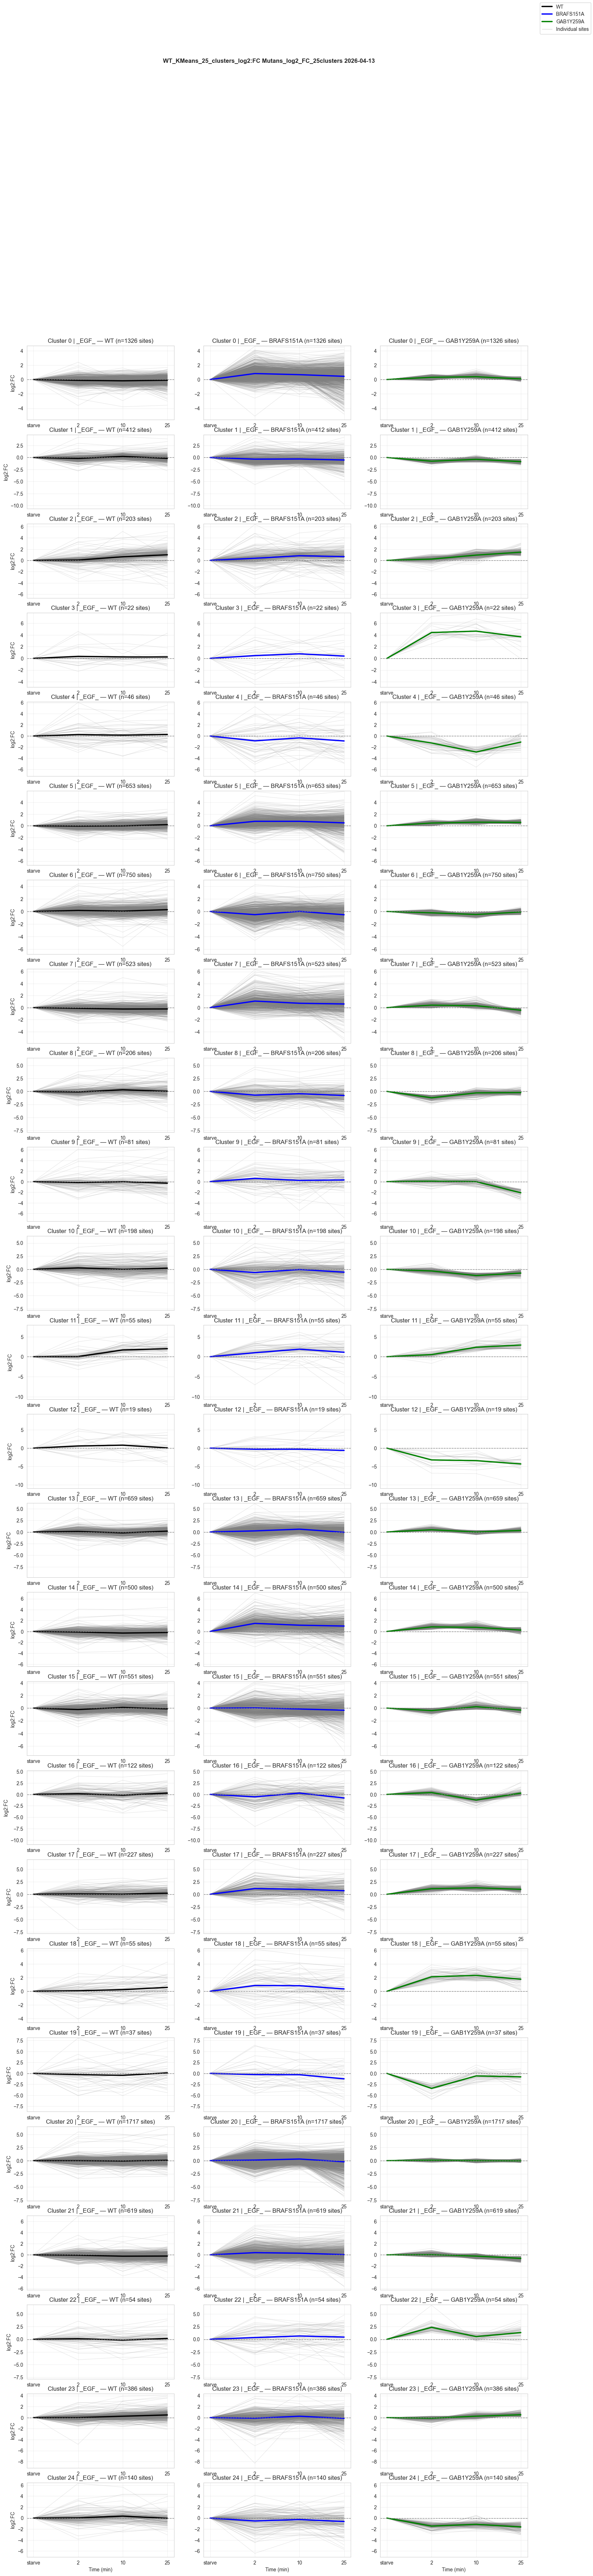

In [59]:
clusters_plot_linear_mutants(
        df = kmeans_clustered,
        legend=["1.57nM EGF", "100nM INS", "1.56nM EGF + 100nM INS"],
        saving_path="Experiment/Progress_report/Images",
        cluster_column=cluster_name,
        cluster_name=f"Mutans_log2_FC_25clusters",
        data_type="log2:FC",
        same_cell_lines=False,
        same_condition = True,
        cell_lines= ["WT", "BRAFS151A", "GAB1Y259A"],
        conditions = ["_EGF_"],
        colors={"WT": "black", "BRAFS151A": "blue", "GAB1Y259A": "green"},
        plot_different_data=True,
        saving_info="Mutans_log2_FC_25clusters_y_axis_fixed",
        save_pdf=False,
        save_png=False,
        plot_close=False,
        fit_y_lims=False,
        grey_alpha=0.2,
        grey_lw=0.8,
        mean_lw=2.6
    )

## PCA of cluster dimentional space

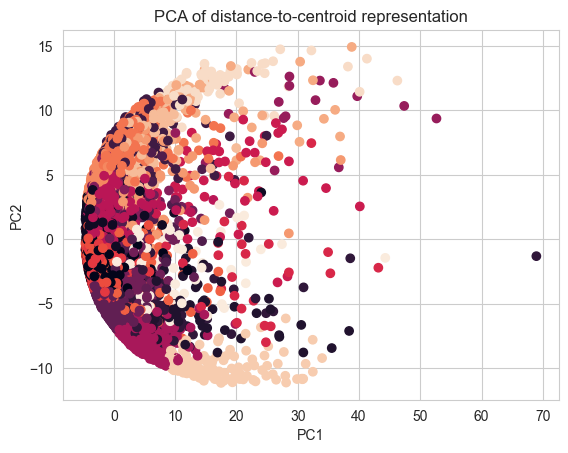

In [85]:
from sklearn.decomposition import PCA

Z = PCA(n_components=10).fit_transform(barycenters)

plt.figure()
plt.scatter(Z[:, 0], Z[:, 1], c=clustering.labels_)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of distance-to-centroid representation")
# plt.savefig(f"Experiment/Progress_report/Images/25_clusters_log2_FC_PCA_distance_to_centroids_MUTANTS.png")
# plt.savefig(f"Experiment/Progress_report/Images/25_clusters_log2_FC_PCA_distance_to_centroids_MUTANTS.pdf")
plt.show()

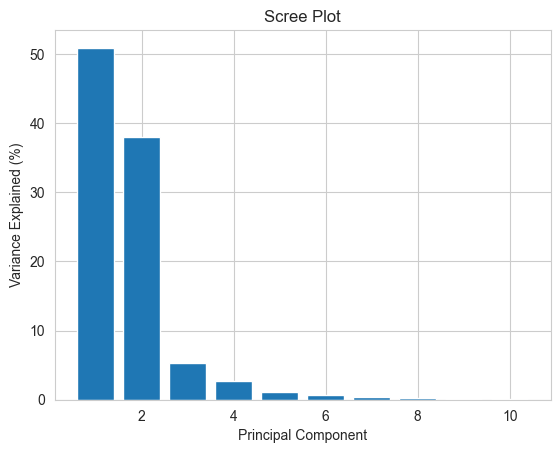

In [86]:
pca = PCA(n_components=10)
pcs = pca.fit_transform(barycenters)

explained = pca.explained_variance_ratio_ * 100
pc_df = pd.DataFrame(pcs, index= clustering.labels_, #df_t.index,
                     columns=[f'PC{i+1}' for i in range(pcs.shape[1])])

# colors = [get_color(s) for s in pc_df.index]

plt.bar(range(1, len(explained)+1), explained)
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained (%)')
plt.title('Scree Plot')
plt.show()

## plotting clusters

In [33]:
def clusters_plot_linear_mutants(
    df,
    legend=list,
    saving_path=str,
    cluster_column=str,
    cluster_name="",
    data_type=str,
    cell_lines=[],
    conditions=[],
    colors={"WT": "black", "BRAFS151A": "blue", "GAB1Y259A": "green"},
    same_cell_lines=False,
    same_condition=False,
    plot_different_data=False,
    saving_info="",
    save_pdf=False,
    save_png=False,
    plot_close=False,
    fit_y_lims=False,
    grey_alpha=0.08,
    grey_lw=0.8,
    mean_lw=2.6):

    if type(df) == pd.DataFrame:
        pass
    else:
        df = pd.read_excel(df)

    if save_pdf or save_png:
        if not os.path.exists(saving_path):
            print("Creating saving folder")
            os.makedirs(saving_path)

    clusters = list(set(df[cluster_column]))
    if 999 in clusters:
        clusters.remove(999)

    if data_type not in cluster_column and plot_different_data == False:
        print("Remember to plot the same data_type used to make the clustering or put: plot_different_data = TRUE")
        return

    # Sort clusters
    if type(clusters[0]) == int:
        sorted_clusters = sorted(clusters)
    else:
        sorted_clusters = sorted(clusters, key=lambda x: int(x.split()[1]))

    n_cluster = len(sorted_clusters)

    # Time points
    column_names = df.columns.tolist()
    x_axis_previous = [col for col in column_names if f"{cell_lines[0]}_{data_type}{conditions[0]}" in col]
    time_points = [s.split("_")[3] for s in x_axis_previous]
    # print(time_points)

    # Build column lookup
    columns_dir = {condition: {cell: {} for cell in cell_lines} for condition in conditions}
    column_selection = []
    sub_dtp = data_type.split(":")

    for condition in conditions:
        for cell in cell_lines:
            values = [
                col for col in column_names
                if col.startswith(cell)
                and condition in col
                and sub_dtp[0] in col
                and sub_dtp[1] in col
            ]
            columns_dir[condition][cell]["plotting"] = values
            column_selection = column_selection + values
    # print(columns_dir)

    fig, axes = plt.subplots(
        nrows=n_cluster,
        ncols=len(cell_lines),
        figsize=(6 * len(cell_lines), max(3.2 * n_cluster, 6)),
        squeeze=False
    )

    for r, cluster in enumerate(sorted_clusters):
        sub_df = df.loc[df[cluster_column] == cluster].copy()

        # Resolve y-axis limits up front
        if isinstance(fit_y_lims, list):
            y_lim_min, y_lim_max = fit_y_lims[0], fit_y_lims[1]
            y_limt_info = f"_y_axis_fixed_{y_lim_min}_{y_lim_max}"
            use_fixed_ylims = True
        elif fit_y_lims is False:
            sub_values_df = sub_df[column_selection] if column_selection else pd.DataFrame()
            if not sub_values_df.empty:
                y_lim_max = sub_values_df.max().max() * 1.02
                y_lim_min = sub_values_df.min().min()
                y_lim_min = y_lim_min + y_lim_min * 0.1 if y_lim_min < 0 else y_lim_min * 0.97
            else:
                y_lim_min, y_lim_max = None, None
            use_fixed_ylims = False
            y_limt_info = ""
        else:  # fit_y_lims is True -> per-row dynamic limits
            use_fixed_ylims = None  # signals "compute per row"
            y_limt_info = "y_axis_perrow"

        if sub_df.shape[0] == 0:
            continue
        # print(cell_lines)
        for c, cell in enumerate(cell_lines):
            ax = axes[r, c]
            # print(r,c)

            color = colors[cell]
            # print(color)
            cond_cols = columns_dir[condition][cell]["plotting"]

            mat = sub_df[cond_cols].to_numpy(dtype=float)
            for i in range(mat.shape[0]):
                ax.plot(time_points, mat[i, :], color="grey", alpha=grey_alpha, linewidth=grey_lw)

            mean_curve = np.nanmean(mat, axis=0)
            ax.plot(time_points, mean_curve, color=color, linewidth=mean_lw)

            ax.axhline(0, color="grey", linestyle="--", linewidth=1)
            ax.grid(True, alpha=0.3)

            # Apply y-limits
            # if use_fixed_ylims is None:  # per-row dynamic
            #     df_val = sub_values_df[cond_cols].to_numpy(dtype=float)
            #     row_vals = row[column_selection].dropna() if column_selection else pd.Series()
            #
            #     if not row_vals.empty:
            #         rmin, rmax = row_vals.min(), row_vals.max()
            #         pad_min = rmin + rmin * 0.1 if rmin < 0 else rmin * 0.9
            #         ax.set_ylim(pad_min, rmax * 1.1)
            # elif use_fixed_ylims and y_lim_min is not None:
            #     axes[i, j].set_ylim(y_lim_min, y_lim_max)
            # elif not use_fixed_ylims and y_lim_min is not None:
            ax.set_ylim(y_lim_min, y_lim_max)

            # ax.set_xlim(-1, 4)

            if r == n_cluster - 1:
                ax.set_xlabel("Time (min)")
            ax.set_ylabel(f"{data_type}" if c == 0 else "")
            ax.set_title(f"Cluster {cluster} | {condition} — {cell} (n={sub_df.shape[0]} sites)")

            ax.set_xticks(range(len(time_points)))
            ax.set_xticklabels([str(t) for t in time_points])

    # Legend always by cell line
    handles = [
        plt.Line2D([0], [0], color=colors.get(cl, "black"), lw=mean_lw)
        for cl in cell_lines
    ] + [plt.Line2D([0], [0], color="grey", lw=grey_lw, alpha=0.4)]
    labels = list(cell_lines) + ["Individual sites"]
    fig.legend(handles, labels, loc="upper right", ncol=1)

    fig.suptitle(f"{cluster_column} {cluster_name} {date.today()}", weight="bold")

    if save_pdf:
        plt.savefig(f"{saving_path}/{cluster_name}{saving_info}.pdf", bbox_inches="tight")
        print(f"{cluster_name}{saving_info} Plot saved as PDF")
    if save_png:
        plt.savefig(f"{saving_path}/{cluster_name}{saving_info}.png", bbox_inches="tight", dpi=300)
        print(f"{cluster_name}{saving_info} Plot saved as PNG")
    if not save_pdf and not save_png:
        print(f"{cluster_name}{saving_info} Plot not saved")

    if plot_close:
        plt.close(fig)


Mutans_log2_FC_25clustersMutans_log2_FC_25clusters_y_axis_fixed Plot not saved


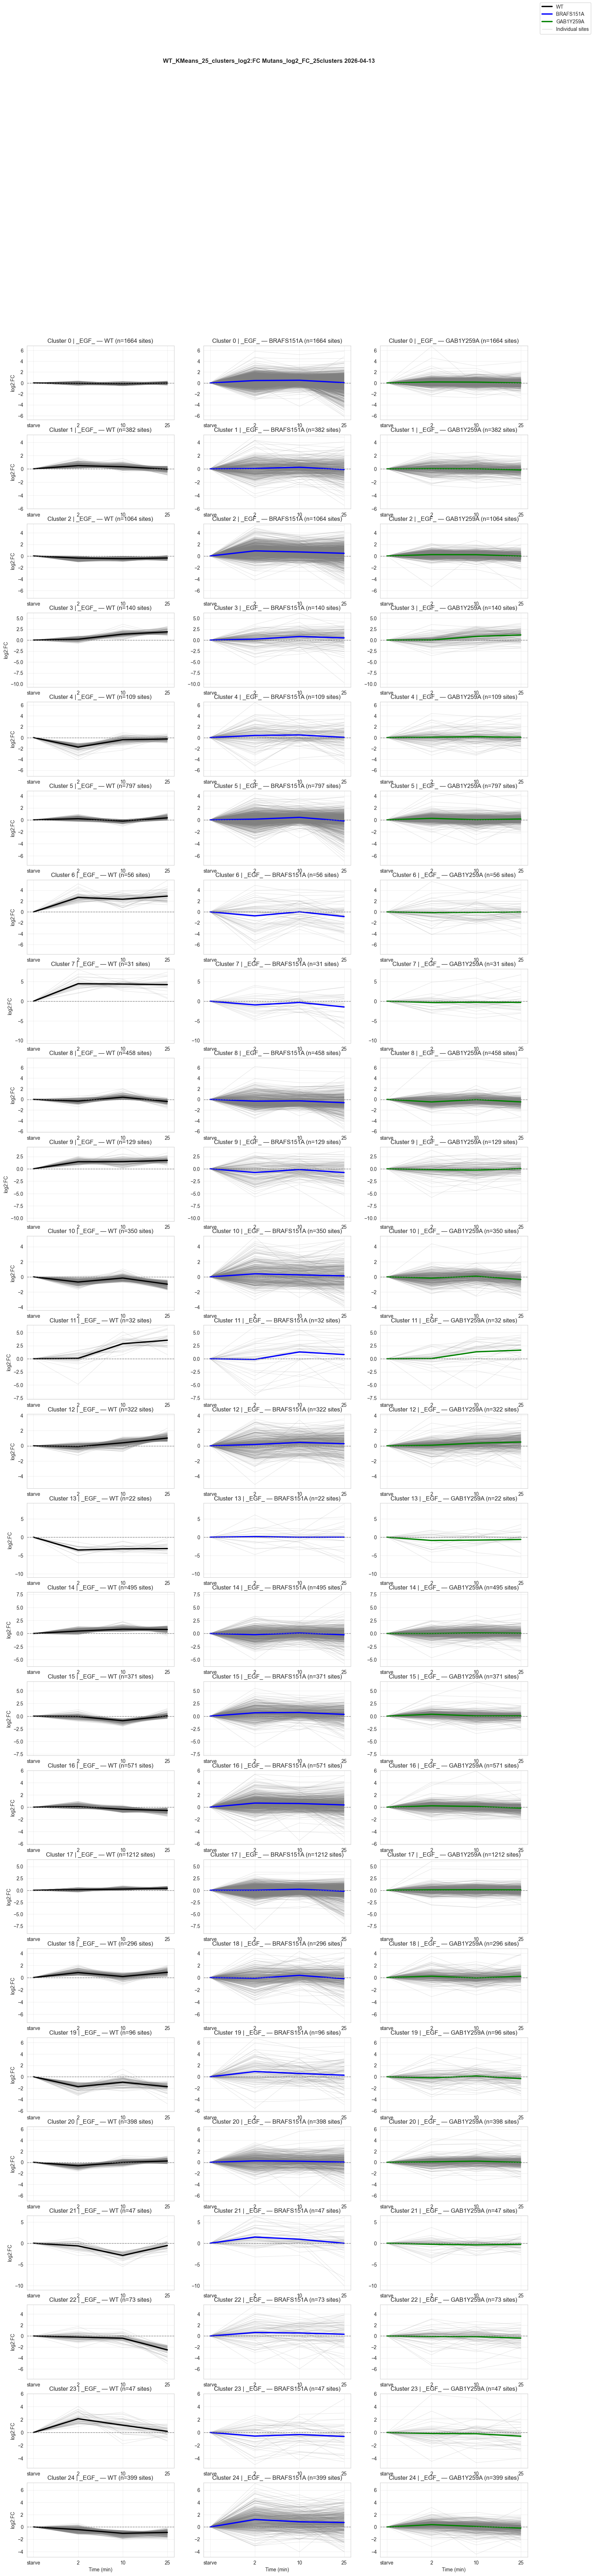

In [34]:
clusters_plot_linear_mutants(
        df = kmeans_clustered,
        legend=["1.57nM EGF", "100nM INS", "1.56nM EGF + 100nM INS"],
        saving_path="Experiment/Progress_report/Images",
        cluster_column=cluster_name,
        cluster_name=f"Mutans_log2_FC_25clusters",
        data_type="log2:FC",
        same_cell_lines=False,
        same_condition = True,
        cell_lines= ["WT", "BRAFS151A", "GAB1Y259A"],
        conditions = ["_EGF_"],
        colors={"WT": "black", "BRAFS151A": "blue", "GAB1Y259A": "green"},
        plot_different_data=True,
        saving_info="Mutans_log2_FC_25clusters_y_axis_fixed",
        save_pdf=False,
        save_png=False,
        plot_close=False,
        fit_y_lims=False,
        grey_alpha=0.2,
        grey_lw=0.8,
        mean_lw=2.6
    )

## Check wich proteins are in a cluster

In [93]:
sub_df = kmeans_clustered.loc[kmeans_clustered[cluster_name] == 13]
protein_list = sub_df["protein_name"].unique().tolist()
# uniprot_links_for(sub_df, protein_list)

## Check in which clusters a protein appear

In [48]:
protein = "EGFR"
protein_df = kmeans_clustered.loc[kmeans_clustered["protein_name"] == protein]
# protein_df = df.loc[df["protein_name"] == protein]
protein_df[["protein_name", "site", cluster_name]]

,protein_name,site,testing_clustering
29638,EGFR,P00533_687_705_1_1_False_T693,2
46656,EGFR,P00533_109_129_1_0_False_M111,18
49049,EGFR,P00533_1161_1179_1_1_False_Y1172,7
49050,EGFR,P00533_1161_1179_1_1_False_S1166,14
49546,EGFR,P00533_1189_1199_1_1_False_Y1197,7
89746,EGFR,P00533_987_999_1_1_False_S991,10


## Plotting all sites of a protein

Plotting sites of protein: P36507
MAP2K2_P36507_log2:FC_ — plot not saved
Plotting sites of protein: Q13233
MAP3K1_Q13233_log2:FC_ — plot not saved


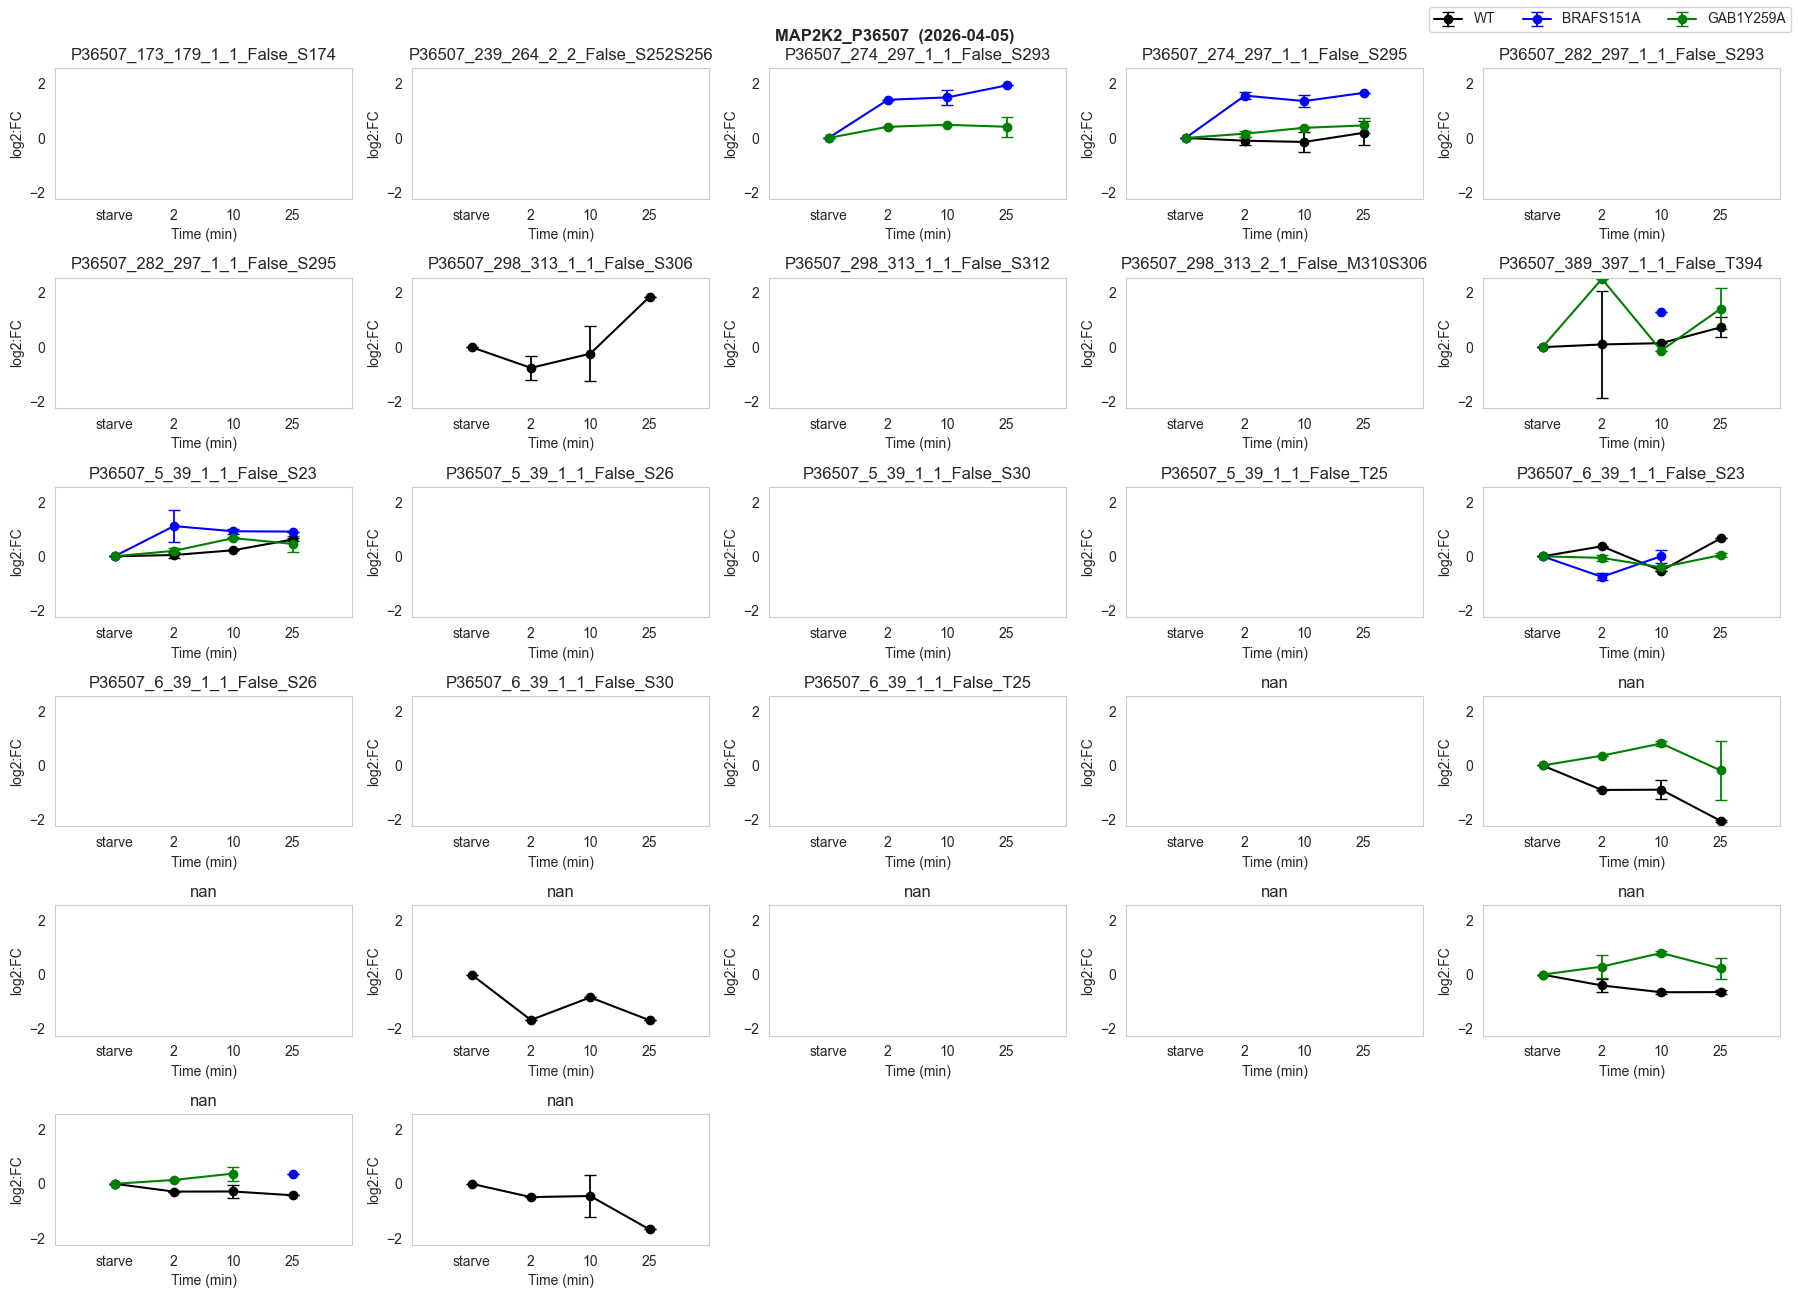

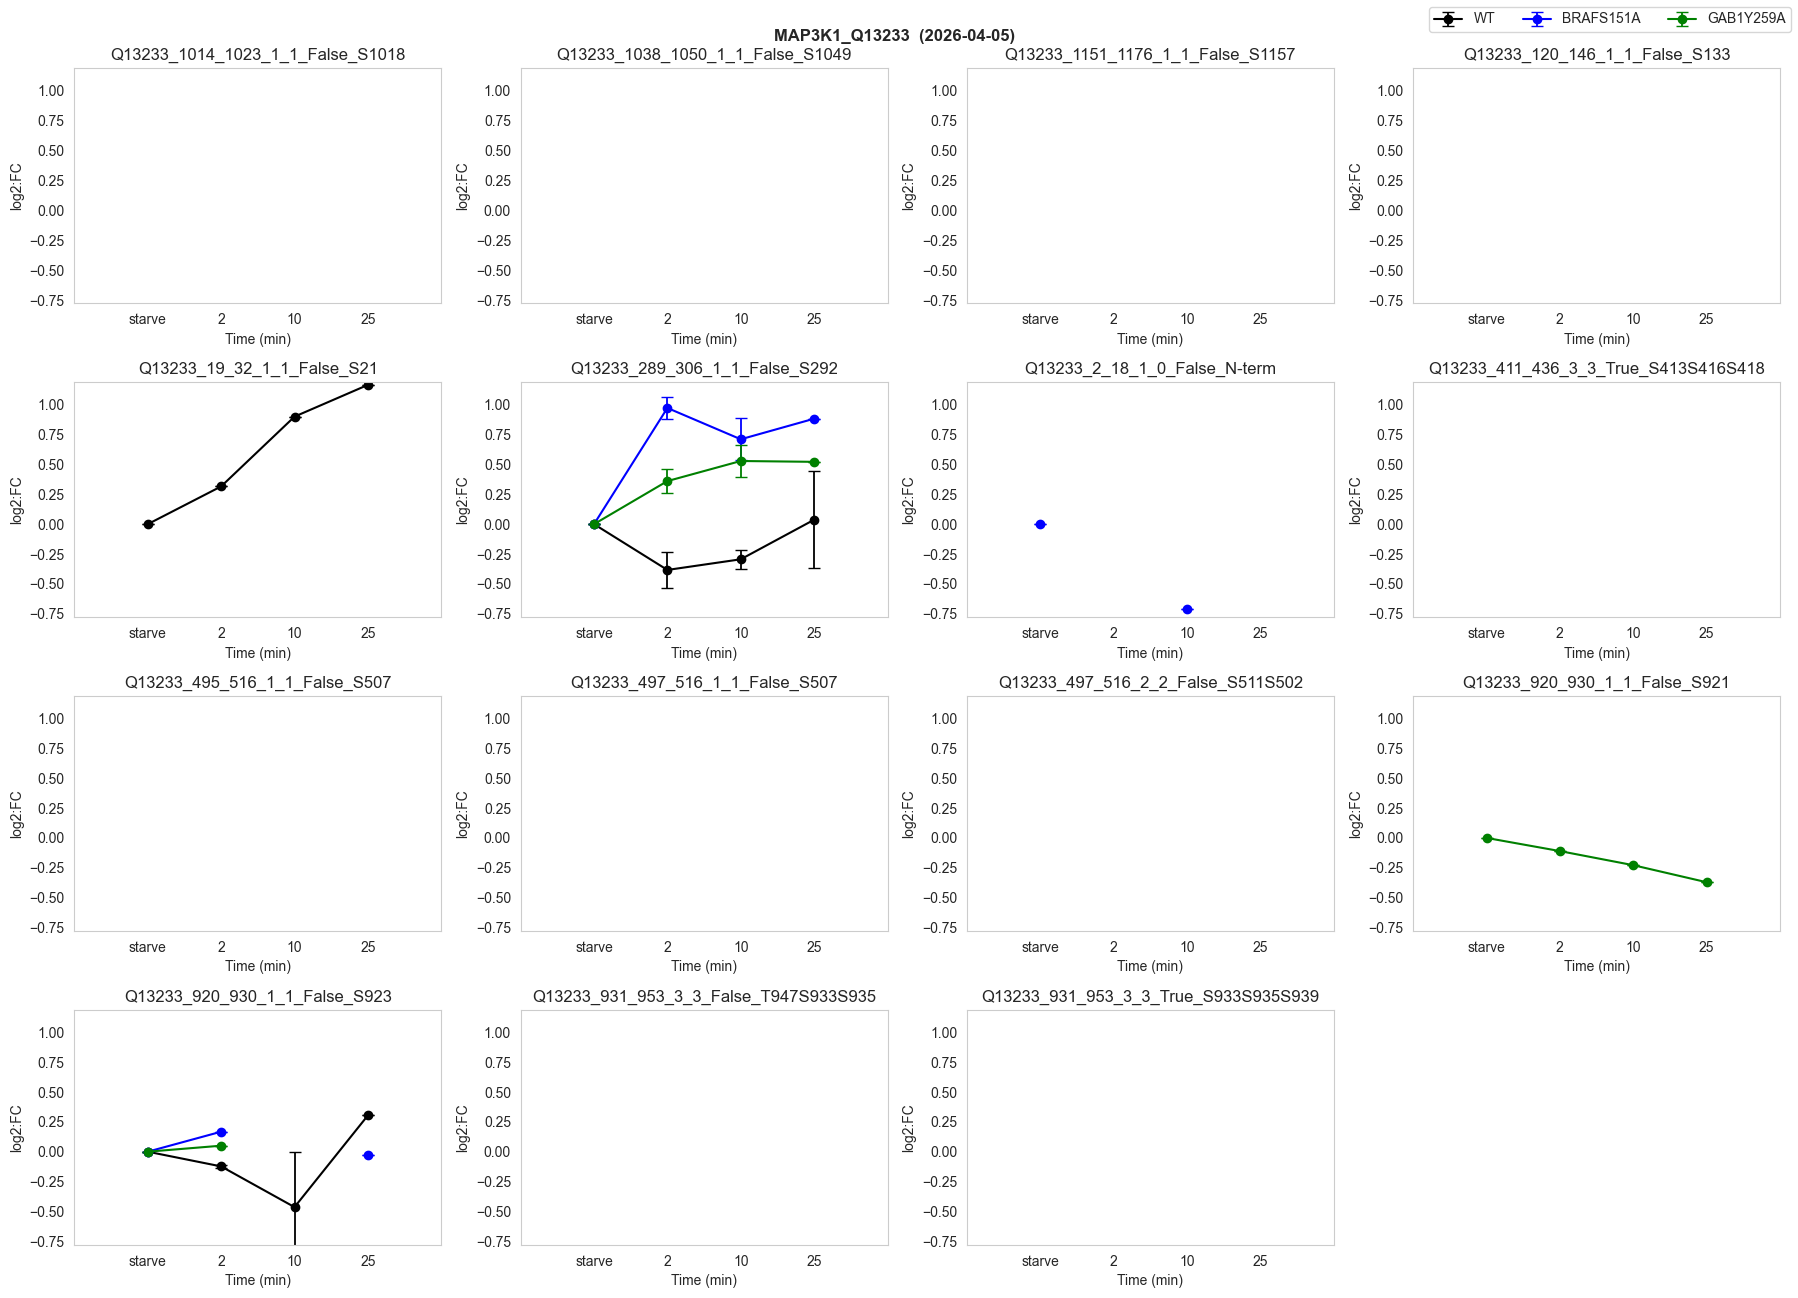

In [70]:
plot_mutants_protein_phosphosites(df = df, #kmeans_clustered
                                   proteins=["P36507", "Q13233"],
                                   data_type= "log2:FC",
                                   saving_path = "",
                                   legend_plot=["WT", "BRAFS151A", "GAB1Y259A"],
                                   cell_lines = ["WT", "BRAFS151A", "GAB1Y259A"],
                                   conditions = ["_EGF_"],
                                   color_palette = {"WT" : "black",
                                                 "BRAFS151A" : "blue",
                                                 "GAB1Y259A" : "green"},
                                   fit_y_lims= False
                     )

## plot protein profile

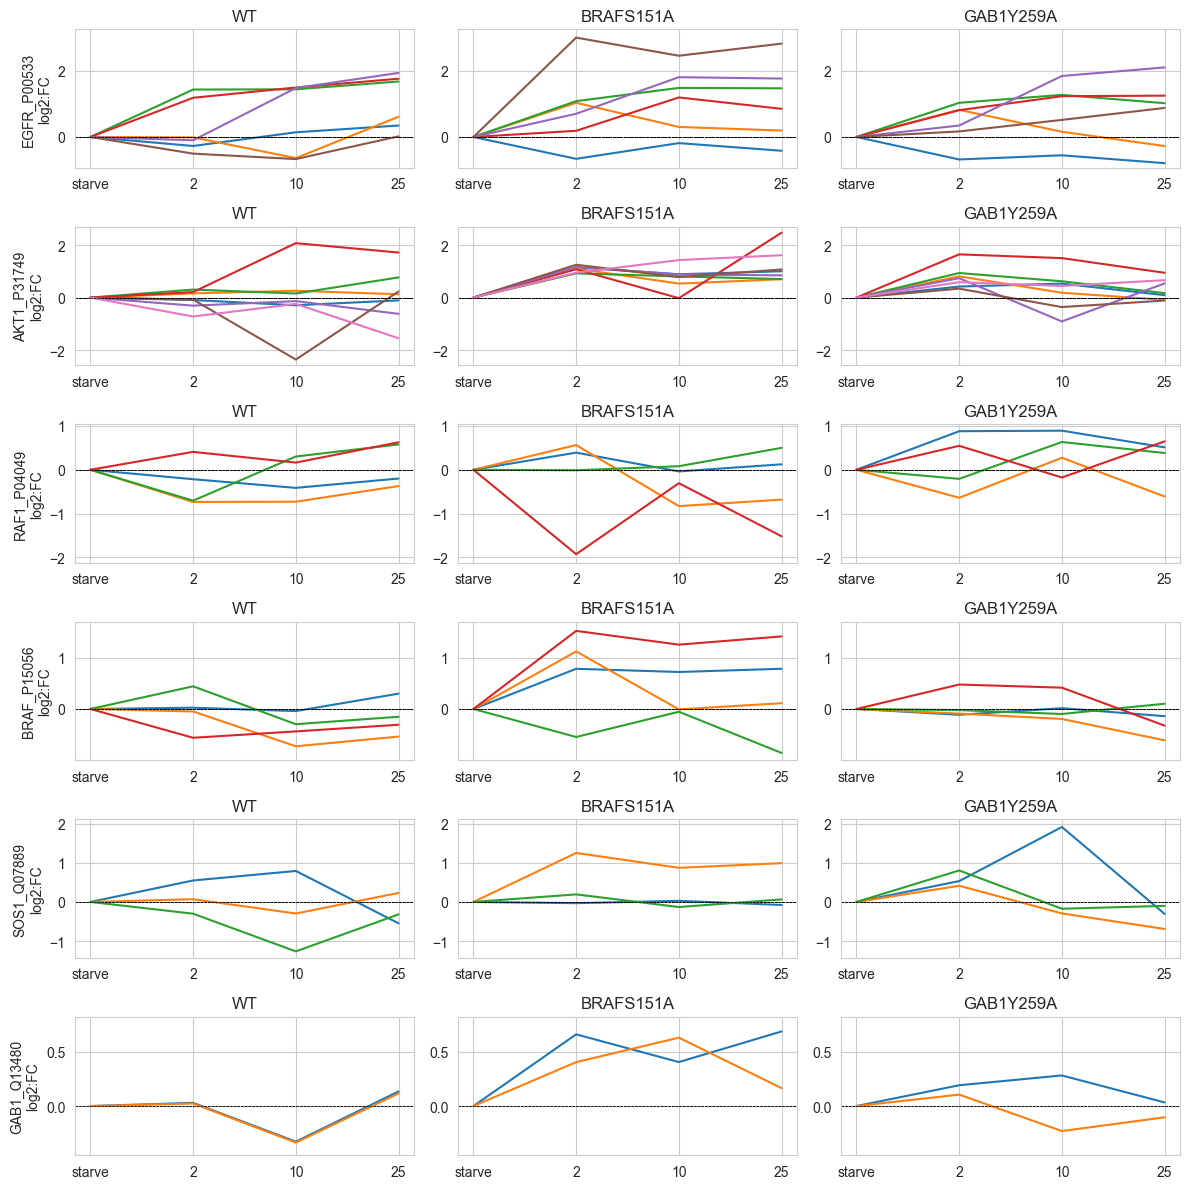

In [46]:
plot_protein_profile_mutants(df = df_filtered,
                                 proteins = ["EGFR", "AKT1", "RAF1", "BRAF", "SOS1", "GAB1"],
                                 data_type = "log2:FC",
                                 cell_lines = ["WT", "BRAFS151A", "GAB1Y259A"],
                                 conditions = ["_EGF_"],
                                 saving_path="Experiment/Progress_report/Images/Individual_prot_profiles",
                                 saving_info="compact_mutants",
                                 legend=False,
                                 save_pdf=False,
                                 save_png=False)

## Imputing kinases for a cluster

In [18]:
import kinase_library as kl
sub_df = kmeans_clustered.loc[kmeans_clustered[cluster_name] == 6]

sub_df["site_sequence"] = (sub_df["Modified_Sequence"].str.replace("S[79.9663]", "s", regex=False)
                    .str.replace("T[79.9663]", "t", regex=False)
                    .str.replace("Y[79.9663]", "y", regex=False)
                    .str.replace("[15.9949]", "", regex=False))


def extract_window(seq, left=6, right=6):
    for i, char in enumerate(seq):
        if char.islower():
            start = max(0, i - left)
            end = min(len(seq), i + right + 1)
            window_seq = seq[start:end]
            left_pad = "_" * max(0, left - i)
            right_pad = "_" * max(0, (i + right + 1) - len(seq))
            return (left_pad + window_seq + right_pad)
    return None

sub_df["site_sequence"] = sub_df["site_sequence"].apply(extract_window)
sub_df

/var/folders/jj/dfknz6j944d69gcp558vh1j80000gn/T/ipykernel_4012/1173144714.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df["site_sequence"] = (sub_df["Modified_Sequence"].str.replace("S[79.9663]", "s", regex=False)
/var/folders/jj/dfknz6j944d69gcp558vh1j80000gn/T/ipykernel_4012/1173144714.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df["site_sequence"] = sub_df["site_sequence"].apply(extract_window)


,protein_Id,protein_name,description,Peptide_Sequence,Modified_Sequence,site_start,site_end,Peptide_Length,Charges,Assigned_Modifications,...,BRAFS151A_log2:FC_EGF_starve,BRAFS151A_log2:FC_EGF_2,BRAFS151A_log2:FC_EGF_10,BRAFS151A_log2:FC_EGF_25,GAB1Y259A_log2:FC_EGF_starve,GAB1Y259A_log2:FC_EGF_2,GAB1Y259A_log2:FC_EGF_10,GAB1Y259A_log2:FC_EGF_25,testing_clustering,site_sequence
191,Q8NB78,KDM1B,Lysine-specific histone demethylase 2,AAATGNASPGKLEHSK,AAATGNAS[79.9663]PGKLEHSK,240,255,16,"2,3",8S(79.9663),...,0.0,1.774133,0.976294,1.429696,0.0,-0.046432,-0.054438,-0.522374,6,AATGNAsPGKLEH
244,Q9HCE3,ZNF532,Zinc finger protein 532,AADKSPESQNLIDGTK,AADKS[79.9663]PESQNLIDGTK,310,325,16,"2,3",5S(79.9663),...,0.0,1.237002,0.826151,1.112161,0.0,0.431826,0.197446,0.084388,6,__AADKsPESQNL
264,O60784,TOM1,Target of Myb1 membrane trafficking protein,AADRLPNLSSPSAEGPPGPPSGPAPR,AADRLPNLSS[79.9663]PSAEGPPGPPSGPAPR,453,478,26,"2,3",10S(79.9663),...,0.0,1.500078,0.385258,1.737912,0.0,-0.058932,0.380689,0.884949,6,RLPNLSsPSAEGP
278,P12270,TPR,Nucleoprotein TPR,AADSQNSGEGNTGAAESSFSQEVSR,AADSQNSGEGNTGAAES[79.9663]SFSQEVSR,2031,2055,25,2,17S(79.9663),...,0.0,1.742221,1.334018,1.369025,0.0,0.033763,0.779344,0.231442,6,NTGAAEsSFSQEV
297,Q9UBB5,MBD2,Methyl-CpG-binding domain protein 2,AADTEEMDIEMDSGDEA,AADTEEMDIEMDS[79.9663]GDEA,395,411,17,2,13S(79.9663),...,0.0,0.832612,2.066360,0.402244,0.0,0.705177,0.157521,0.365415,6,MDIEMDsGDEA__
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174462,P11387,TOP1,DNA topoisomerase 1,SGDHLHNDSQIEADFR,n[42.0106]SGDHLHNDSQIEADFR,2,17,16,"2,3",N-term(42.0106),...,0.0,1.715043,1.014374,1.241874,0.0,0.242644,0.215907,0.161267,6,______n[42.01
174830,P10412,H1-4,Histone H1.4,SETAPAAPAAPAPAEKTPVK,n[42.0106]S[79.9663]ETAPAAPAAPAPAEKT[79.9663]PVK,2,21,20,2,"N-term(42.0106),17T(79.9663),1S(79.9663)",...,0.0,0.900697,0.868577,0.933125,0.0,0.182760,-0.056706,-0.213530,6,______n[42.01
174845,P16402,H1-3,Histone H1.3,SETAPLAPTIPAPAEKTPVKK,n[42.0106]S[79.9663]ETAPLAPTIPAPAEKT[79.9663]PVKK,2,22,21,"2,3","N-term(42.0106),17T(79.9663),1S(79.9663)",...,0.0,0.948154,0.847600,0.735225,0.0,0.403468,0.181852,0.322091,6,______n[42.01
174869,A0A2R8Y4L2,HNRNPA1L3,Heterogeneous nuclear ribonucleoprotein A1-like 3,SKSESPKEPEQLR,n[42.0106]S[79.9663]KSES[79.9663]PKEPEQLR,2,14,13,"2,3","N-term(42.0106),1S(79.9663),5S(79.9663)",...,0.0,1.628380,1.223493,1.552139,0.0,0.343611,0.283059,-0.018416,6,______n[42.01


In [97]:
pps = kl.PhosphoProteomics(sub_df, seq_col="site_sequence", pp=True)

8 entries were omitted due to empty value in the substrates column.
27 entries were omitted due to invalid amino acids or characters.
Use the 'omited_entries' attribute to view dropped enteries due to invalid sequences.


In [98]:
ranked = pps.rank(metric='score', kin_type='ser_thr')


Scoring 374 ser_thr substrates


In [99]:
kinase_cols = ranked.columns[140:]
sub_df["top_kinase"] = ranked[kinase_cols].idxmin(axis=1)
sub_df["top_kinase"]
kinase_counts = sub_df["top_kinase"].value_counts()
kinase_counts

/var/folders/jj/dfknz6j944d69gcp558vh1j80000gn/T/ipykernel_24929/257152233.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df["top_kinase"] = ranked[kinase_cols].idxmin(axis=1)


top_kinase
CK2A1     76
CK2A2     70
FAM20C    15
P38D      13
PLK2      12
          ..
CK1G3      1
CHAK2      1
CDK7       1
TBK1       1
GRK4       1
Name: count, Length: 90, dtype: int64

## Diferential expression of imputed kinases

In [29]:
cluster_6 = sub_df.loc[sub_df["testing_clustering"] == 6]

testing = cluster_6[["site_sequence", "BRAFS151A_log2:abs_EGF_starve_r1", "BRAFS151A_log2:abs_EGF_2_r1", "BRAFS151A_log2:abs_EGF_2_r2"]].copy()

In [30]:
from scipy import stats
import numpy as np
from statsmodels.stats.multitest import multipletests

def impute_by_copy(vals: np.ndarray) -> np.ndarray:
    """If exactly one value is NaN in a 2-replicate array, copy the other."""
    if len(vals) == 2 and np.sum(np.isnan(vals)) == 1:
        valid = vals[~np.isnan(vals)][0]
        return np.array([valid, valid])
    return vals

def add_ttest_starve_vs_EGF2(df):
    """
    Compares EGF_starve (n=1) vs EGF_2 (n=2, with optional imputation)
    by pooling into groups of n=3. Appends results as new columns.
    """
    col_starve = "BRAFS151A_log2:abs_EGF_starve_r1"
    col_egf2   = ["BRAFS151A_log2:abs_EGF_2_r1", "BRAFS151A_log2:abs_EGF_2_r2"]

    t_stats, p_values, log2_fcs, imputed_flags = [], [], [], []

    for _, row in df.iterrows():
        a_val = np.array([row[col_starve]], dtype=float)   # n=1, no imputation needed
        b_vals = np.array(row[col_egf2].values, dtype=float)  # n=2, may have NaN

        # Impute missing replicate in exp2 by copying the valid one
        b_vals = impute_by_copy(b_vals)
        was_imputed = np.any(np.isnan(row[col_egf2].values.astype(float)))
        imputed_flags.append(was_imputed)

        # Pool: condition A = [starve_r1], condition B = [egf2_r1, egf2_r2]
        a_pool = a_val[~np.isnan(a_val)]
        b_pool = b_vals[~np.isnan(b_vals)]

        # Need at least 2 values per group after imputation
        if len(a_pool) < 2 or len(b_pool) < 2:
            t_stats.append(np.nan)
            p_values.append(np.nan)
            log2_fcs.append(np.mean(b_pool) - np.mean(a_pool) if len(a_pool) > 0 and len(b_pool) > 0 else np.nan)
            continue

        t_stat, p_val = stats.ttest_ind(a_pool, b_pool, equal_var=False)
        log2_fc = np.mean(b_pool) - np.mean(a_pool)  # EGF2 - starve

        t_stats.append(t_stat)
        p_values.append(p_val)
        log2_fcs.append(log2_fc)

    df["ttest_tstat"]    = t_stats
    df["ttest_pval"]     = p_values
    df["ttest_log2FC"]   = log2_fcs  # positive = higher in EGF2 vs starve
    df["ttest_imputed"]  = imputed_flags  # flag so you know which rows were imputed

    # BH correction on valid p-values
    valid_mask = df["ttest_pval"].notna()
    if valid_mask.sum() > 0:
        _, p_adj, _, _ = multipletests(df.loc[valid_mask, "ttest_pval"], method="fdr_bh")
        df["ttest_pval_adj"] = np.nan
        df.loc[valid_mask, "ttest_pval_adj"] = p_adj

    return df


# Usage
testing = add_ttest_starve_vs_EGF2(testing)
testing

,site_sequence,BRAFS151A_log2:abs_EGF_starve_r1,BRAFS151A_log2:abs_EGF_2_r1,BRAFS151A_log2:abs_EGF_2_r2,ttest_tstat,ttest_pval,ttest_log2FC,ttest_imputed
191,AATGNAsPGKLEH,17.539590,18.881345,19.746102,NaN,NaN,1.774133,False
244,__AADKsPESQNL,17.001468,17.995209,18.481731,NaN,NaN,1.237002,False
264,RLPNLSsPSAEGP,18.314234,19.814312,NaN,NaN,NaN,1.500078,True
278,NTGAAEsSFSQEV,15.410613,17.263616,17.042051,NaN,NaN,1.742221,False
297,MDIEMDsGDEA__,16.988034,18.436298,17.204995,NaN,NaN,0.832612,False
...,...,...,...,...,...,...,...,...
174462,______n[42.01,15.976138,17.314703,18.067659,NaN,NaN,1.715043,False
174830,______n[42.01,20.755193,21.613998,21.697782,NaN,NaN,0.900697,False
174845,______n[42.01,16.804838,17.117771,18.388212,NaN,NaN,0.948154,False
174869,______n[42.01,21.140449,22.602298,22.935360,NaN,NaN,1.628380,False


In [24]:
diff_phos_df = kl.DiffPhosData(sub_df, lfc_col = "BRAFS151A_log2:FC_EGF_2", seq_col="site_sequence", suppress_warnings=True)

### Ser/Thr kinases

In [25]:
kin_type = 'ser_thr'
method = 'percentile_rank'
thresh = 15

diff_phos_res = diff_phos_df.kinase_enrichment(kin_type=kin_type, kl_method=method, kl_thresh=thresh)


Calculating percentiles for upregulated sites (1085 substrates)
Scoring 1075 ser_thr substrates
Calculating percentile for 1075 ser_thr substrates
100%|██████████| 311/311 [00:01<00:00, 163.91it/s] 
                                                  

Calculating percentiles for downregulated sites (1 substrates)
Scoring 1 ser_thr substrates
Calculating percentile for 1 ser_thr substrates
100%|██████████| 311/311 [00:01<00:00, 174.85it/s] 
                                                  

Calculating percentiles for background (unregulated) sites (0 substrates)
Scoring 0 ser_thr substrates


In [26]:
diff_phos_res.combined_enrichment_results.sort_values("most_sig_fisher_pval")

,fg_counts_downreg,fg_total_downreg,bg_counts_downreg,bg_total_downreg,fg_percent_downreg,log2_freq_factor_downreg,fisher_pval_downreg,fisher_adj_pval_downreg,fg_counts_upreg,fg_total_upreg,bg_counts_upreg,bg_total_upreg,fg_percent_upreg,log2_freq_factor_upreg,fisher_pval_upreg,fisher_adj_pval_upreg,most_sig_direction,most_sig_log2_freq_factor,most_sig_fisher_pval,most_sig_fisher_adj_pval
AAK1,1,1,0,0,100.0,0.584963,1.0,1.0,70,1075,0,0,6.511628,-2.931911,1.0,1.0,+,-2.931911,1.0,1.0
PAK3,0,1,0,0,0.0,-1.000000,1.0,1.0,10,1075,0,0,0.930233,-5.679145,1.0,1.0,+,-5.679145,1.0,1.0
PAK2,0,1,0,0,0.0,-1.000000,1.0,1.0,8,1075,0,0,0.744186,-5.984000,1.0,1.0,+,-5.984000,1.0,1.0
PAK1,0,1,0,0,0.0,-1.000000,1.0,1.0,14,1075,0,0,1.302326,-5.213481,1.0,1.0,+,-5.213481,1.0,1.0
P90RSK,0,1,0,0,0.0,-1.000000,1.0,1.0,2,1075,0,0,0.186047,-7.749534,1.0,1.0,+,-7.749534,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ERK5,0,1,0,0,0.0,-1.000000,1.0,1.0,112,1075,0,0,10.418605,-2.257681,1.0,1.0,+,-2.257681,1.0,1.0
ERK2,0,1,0,0,0.0,-1.000000,1.0,1.0,154,1075,0,0,14.325581,-1.799999,1.0,1.0,+,-1.799999,1.0,1.0
ERK1,0,1,0,0,0.0,-1.000000,1.0,1.0,125,1075,0,0,11.627907,-2.099919,1.0,1.0,+,-2.099919,1.0,1.0
GCN2,0,1,0,0,0.0,-1.000000,1.0,1.0,77,1075,0,0,7.162791,-2.795338,1.0,1.0,+,-2.795338,1.0,1.0


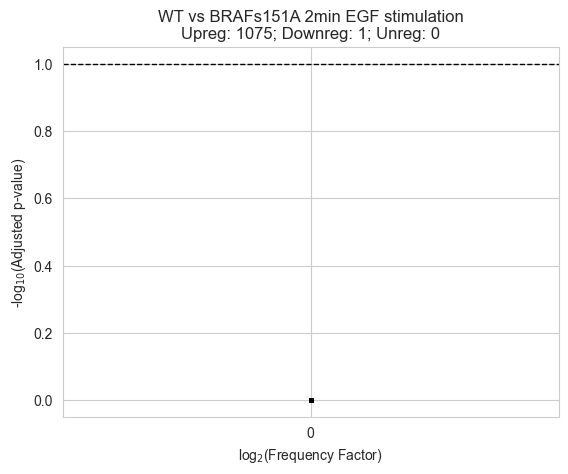

In [27]:
diff_phos_res.plot_volcano(title='WT vs BRAFs151A 2min EGF stimulation')

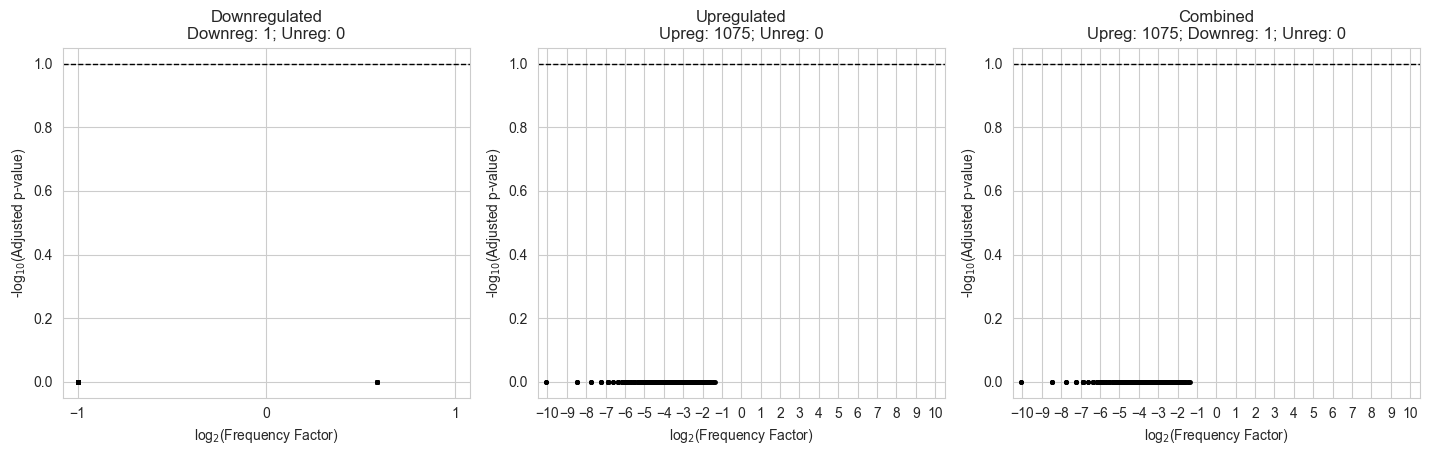

In [28]:
diff_phos_res.plot_down_up_comb_volcanos()

### Tyr kinases


Calculating percentiles for upregulated sites (248 substrates)
Scoring 1 tyrosine substrates
Calculating percentile for 1 tyrosine substrates
100%|██████████| 78/78 [00:00<00:00, 1838.31it/s]
                                                 

Calculating percentiles for downregulated sites (129 substrates)
Scoring 2 tyrosine substrates
Calculating percentile for 2 tyrosine substrates
100%|██████████| 78/78 [00:00<00:00, 2651.27it/s]
                                                 

Calculating percentiles for background (unregulated) sites (0 substrates)
Scoring 0 tyrosine substrates


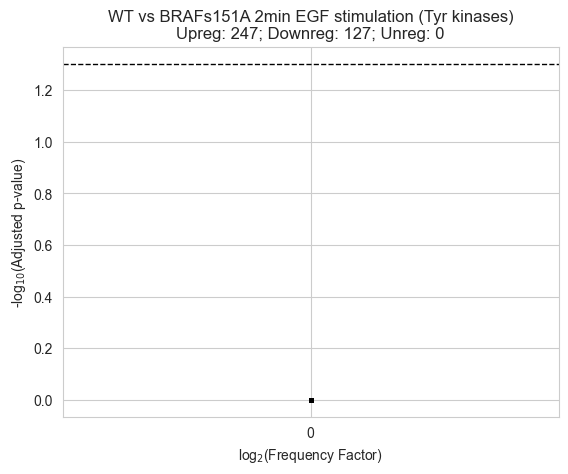

In [16]:
#tyr
kin_type = 'tyrosine'
method = 'percentile_rank'
thresh = 8

diff_phos_res_tyr = diff_phos_df.kinase_enrichment(kin_type=kin_type, kl_method=method, kl_thresh=thresh)

diff_phos_res.plot_volcano(title='WT vs BRAFs151A 2min EGF stimulation (Tyr kinases)', adj_pval=False, sig_pval=0.05)



### Multiple comparisons

# Dimentionality reduction

In [54]:
# # Plotting functions
# Map time points to shade intensity (lighter = earlier, darker = later)
timepoint_shades = {
    "starve": 0.3,
    "2":      0.5,
    "10":     0.75,
    "25":     1.0
}

# Base colors per cell line as RGB for shade blending
base_colors_rgb = {
    "WT":        np.array([0, 0, 0]),        # black
    "BRAFS151A": np.array([0, 0, 1]),        # blue
    "GAB1Y259A": np.array([0, 0.5, 0])      # green
}

def get_color(sample_name):
    # Identify cell line
    if sample_name.startswith("WT"):
        cell_line = "WT"
    elif sample_name.startswith("BRAFS151A"):
        cell_line = "BRAFS151A"
    elif sample_name.startswith("GAB1Y259A"):
        cell_line = "GAB1Y259A"
    else:
        return (0.5, 0.5, 0.5)  # fallback gray

    # Identify time point from the sample name
    if "starve" in sample_name:
        tp = "starve"
    elif "_2_" in sample_name or sample_name.endswith("_2"):
        tp = "2"
    elif "_10_" in sample_name or sample_name.endswith("_10"):
        tp = "10"
    elif "_25_" in sample_name or sample_name.endswith("_25"):
        tp = "25"
    else:
        tp = "25"  # fallback to darkest

    shade = timepoint_shades[tp]
    base  = base_colors_rgb[cell_line]

    # Blend base color with white: shade=1 → full color, shade=0.3 → light
    rgb = 1 - shade * (1 - base)   # white is (1,1,1), so we interpolate toward base
    return tuple(rgb)


# Build color list for all samples
columns = df_filtered.columns.to_list()
selected_columns = [col for col in columns if "log2:abs" in col]
colors = [get_color(s) for s in selected_columns]


def plot_embedding(coords_df, x_col, y_col, title, colors, explained=None):
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(coords_df[x_col], coords_df[y_col],
               c=colors, s=80, edgecolors='white', linewidths=0.5)

    for sample, color in zip(coords_df.index, colors):
        ax.annotate(sample,
                    (coords_df.loc[sample, x_col], coords_df.loc[sample, y_col]),
                    fontsize=7, color=color, ha='left', va='bottom')

    xlabel = f'{x_col} ({explained[0]:.1f}%)' if explained else x_col
    ylabel = f'{y_col} ({explained[1]:.1f}%)' if explained else y_col
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)

    # Legend: cell lines (solid) + time point shades (grey swatches)
    legend_elements = []
    for cell_line, base in base_colors_rgb.items():
        full_color = tuple(1 - 1.0 * (1 - base))  # darkest shade
        legend_elements.append(
            Line2D([0],[0], marker='o', color='w',
                   markerfacecolor=full_color, label=cell_line, markersize=9)
        )
    for tp, shade in timepoint_shades.items():
        gray = (1 - shade * (1 - np.array([0.4, 0.4, 0.4])))
        legend_elements.append(
            Line2D([0],[0], marker='o', color='w',
                   markerfacecolor=tuple(gray), label=f't = {tp}', markersize=7)
        )

    ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
    plt.tight_layout()
    plt.show()


In [55]:
# Select columns for the dimesionality reduction
columns = df_filtered.columns.to_list()
selected_columns = [col for col in columns if "raw:abs" in col]
# print(selected_columns)
sub_df = df_filtered[selected_columns]

# Transpose the dataframe. For the dimensionality reduction we want to apply it on the samples, in this case our samples are the time points and the detected phosphorylation sites are the features detected of the samples. This is why we have to transpose the matrix, puting the time points as rows (samples) and the sites as columns (features)
df_t = sub_df.T

# Deal with missing values, we can remove all columns with missing vaues, replace the missing values with "0", or impute the missing values based on the others
# I should be imputing based on the values of the replicate, not based on the whole column (all samples)
# for condition in replicates:
#     for suf in suffixes:
#         print(f"{condition}{suf}")
df_t = df_t.fillna(df_t.min().min())  # or use imputation

# For dimensionality reduction it is important to scale the data
scaler = StandardScaler()
scaled = scaler.fit_transform(df_t)
# scaled

## PCA

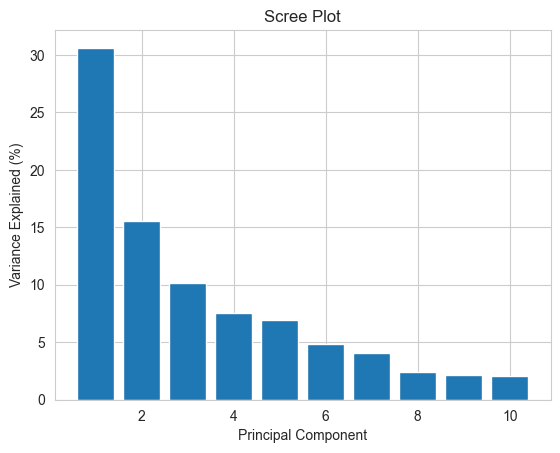

In [56]:
# PCA
pca = PCA(n_components=10)
pcs = pca.fit_transform(scaled)


explained = pca.explained_variance_ratio_ * 100
pc_df = pd.DataFrame(pcs, index=df_t.index,
                     columns=[f'PC{i+1}' for i in range(pcs.shape[1])])

# colors = [get_color(s) for s in pc_df.index]

plt.bar(range(1, len(explained)+1), explained)
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained (%)')
plt.title('Scree Plot')
plt.show()

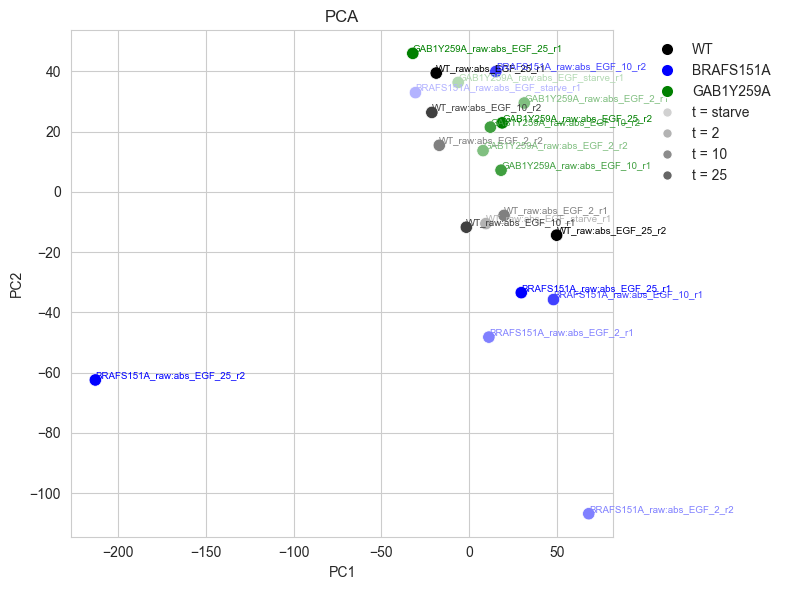

In [95]:
plot_embedding(pc_df, 'PC1', 'PC2', 'PCA',  colors)

## UMAP

/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


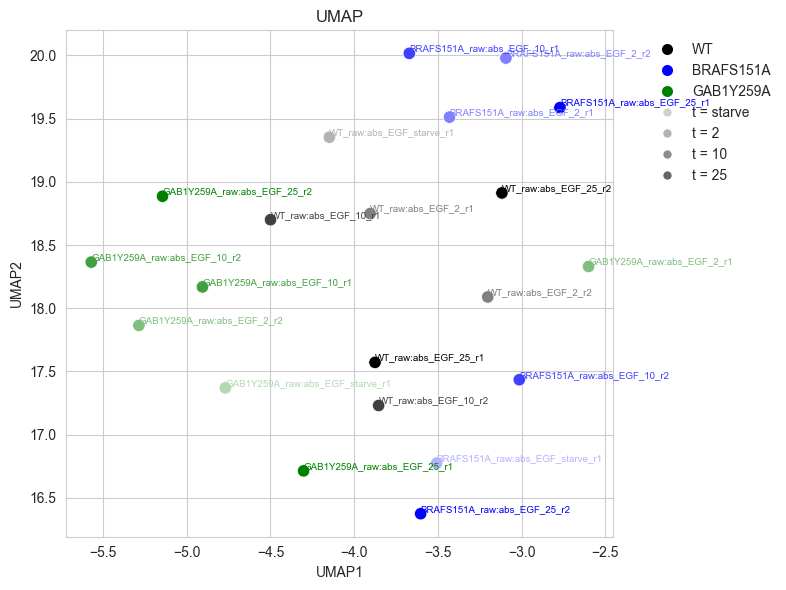

In [58]:
# UMAP

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,     # key param: low = local structure, high = global structure
    min_dist=0.1,       # how tightly points cluster (0.0–1.0)
    random_state=0
)
umap_coords = reducer.fit_transform(scaled) # scaled

umap_df = pd.DataFrame(umap_coords, index=df_t.index, columns=['UMAP1', 'UMAP2'])

plot_embedding(umap_df, 'UMAP1', 'UMAP2', 'UMAP',  colors)

# Similarity with TMT dataset

In [59]:
TMT_dataset = pd.read_csv("Experiment/2_hTERT_HME1/Data/Processed/Full_dataset_2_hTERT_HME1_functional_names_diff_scaled_phPlus_new_naming.tsv", sep='\t')
LFQ_dataset = df_filtered.copy()

## Create column for both dataset with same naming method

In [60]:
TMT_dataset["new_site"] = TMT_dataset["site"].str.split("~").str[0]
TMT_dataset["new_site"] = (TMT_dataset["new_site"].str.split("_").str[0] + "_" + TMT_dataset["new_site"].str.split("_").str[-1])
# TMT_dataset["new_site"]

LFQ_dataset["new_site"] = LFQ_dataset["site"].str.replace("_True", "").replace("_False", "")
LFQ_dataset["new_site"] = LFQ_dataset["new_site"].str.replace("_False", "")
LFQ_dataset["new_site"] = (LFQ_dataset["new_site"].str.split("_").str[0] + "_" + LFQ_dataset["new_site"].str.split("_").str[-1])
# LFQ_dataset["new_site"]

## Select time points to use, and create sub df with them + filtering for redundancy in sites

In [61]:
columns = LFQ_dataset.columns
data_type = "log2:FC"
cell_line = ["WT"]
condition = ["_EGF_"]
times = [2, 10]

time_series = [element for element in columns if element.startswith(cell_line[0])
               and data_type in element
               and condition[0] in element
               ]
print(time_series)
time_series.remove("WT_log2:FC_EGF_25")
print(time_series)

['WT_log2:FC_EGF_starve', 'WT_log2:FC_EGF_2', 'WT_log2:FC_EGF_10', 'WT_log2:FC_EGF_25']
['WT_log2:FC_EGF_starve', 'WT_log2:FC_EGF_2', 'WT_log2:FC_EGF_10']


In [62]:
TMT_sites_list = list(TMT_dataset["new_site"].to_list())
LFQ_sites_list = list(LFQ_dataset["new_site"].to_list())

# Remove sites with more than one count (creates un-paring)
TMT_sites_1_count = [element for element in TMT_sites_list if TMT_sites_list.count(element) == 1]
LFQ_sites_1_count = [element for element in LFQ_sites_list if LFQ_sites_list.count(element) == 1]

common_sites = [site for site in TMT_sites_1_count if site in LFQ_sites_1_count]
print(len(common_sites))
print([common_sites[:10]])

3494
[['A0A2R8Y4L2_S312', 'A0A2R8Y4L2_S313', 'A0A3B3IU46_S36', 'A0FGR8_S691', 'A0FGR8_S693', 'A0FGR8_S755', 'A0FGR8_S761', 'A0FGR8_S755S758S761', 'A0JNW5_S418', 'A0MZ66_T537']]


In [63]:
TMT_dataset.set_index("new_site", drop= False, inplace=True)
TMT_sub_df = TMT_dataset.loc[TMT_dataset["new_site"].isin(common_sites)]
TMT_sub_df = TMT_sub_df[time_series]

LFQ_dataset.set_index("new_site", drop = False,  inplace=True)
LFQ_sub_df = LFQ_dataset.loc[LFQ_dataset["new_site"].isin(common_sites)]
LFQ_sub_df = LFQ_sub_df[time_series]
print(TMT_sub_df.shape, LFQ_sub_df.shape)

TMT_sub_df.sort_index()
LFQ_sub_df.sort_index()

(3494, 3) (3494, 3)


,WT_log2:FC_EGF_starve,WT_log2:FC_EGF_2,WT_log2:FC_EGF_10
new_site,,,
A0A2R8Y4L2_S312,0.0,0.450134,0.578473
A0A2R8Y4L2_S313,0.0,0.706490,0.035908
A0A3B3IU46_S36,0.0,-0.043535,-0.461190
A0FGR8_S691,0.0,0.416992,0.628323
A0FGR8_S693,0.0,-0.507518,-0.540744
...,...,...,...
Q9Y6X4_S378S379,0.0,-0.357974,-0.094400
Q9Y6X4_S526,0.0,-0.209452,-0.104974
Q9Y6X9_S615,0.0,-0.107838,-0.517106


## Calculate euclidean distances. Representation


Euclidean distance summary:
count    3494.000
mean        0.636
std         0.686
min         0.007
25%         0.278
50%         0.469
75%         0.756
max         9.899
Name: euclidean_distance, dtype: float64

  25th percentile : 0.278
  50th percentile : 0.469
  75th percentile : 0.756
  90th percentile : 1.167


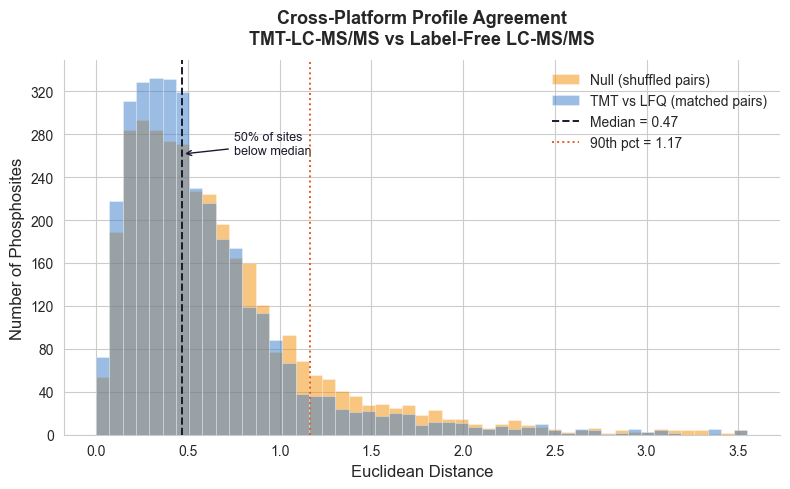

In [64]:
# calculate euclidena distances
diff = TMT_sub_df - LFQ_sub_df
euclidean_distances = np.sqrt(np.sum(diff ** 2, axis=1))

distances = pd.Series(euclidean_distances, index=common_sites, name="euclidean_distance")

print(f"\nEuclidean distance summary:")
print(distances.describe().round(3))

# Percentile thresholds — useful for defining agreement categories later
p25, p50, p75, p90 = np.percentile(euclidean_distances, [25, 50, 75, 90])
print(f"\n  25th percentile : {p25:.3f}")
print(f"  50th percentile : {p50:.3f}")
print(f"  75th percentile : {p75:.3f}")
print(f"  90th percentile : {p90:.3f}")

# =============================================================================
# NULL DISTRIBUTION — distances from randomly shuffled site pairs
# =============================================================================
n_sites = len(common_sites)

rng = np.random.default_rng(seed=42)
n_permutations = n_sites                                 # same number as real distances

shuffled_idx = rng.permutation(n_sites)
# Pair each TMT profile with a random LFQ profile from a different site
lfq_shuffled = LFQ_sub_df.values[shuffled_idx]
diff_null = TMT_sub_df.values - lfq_shuffled
null_distances = np.sqrt(np.sum(diff_null ** 2, axis=1))
# =============================================================================
# HISTOGRAM
# =============================================================================

fig, ax = plt.subplots(figsize=(8, 5))

# Choose bin edges shared across both distributions for a fair visual comparison
all_values = np.concatenate([euclidean_distances, null_distances])
bins = np.linspace(0, np.percentile(all_values, 99), 50)

ax.hist(null_distances, bins=bins, color="#f58e07", edgecolor="white", # color = "#d0d0d0"
        linewidth=0.4, alpha=0.5, label="Null (shuffled pairs)", zorder=2)

ax.hist(euclidean_distances, bins=bins, color="#3A7DC9", edgecolor="white",
        linewidth=0.4, alpha=0.5, label="TMT vs LFQ (matched pairs)", zorder=3)

# Median line
ax.axvline(p50, color="#1a1a2e", linestyle="--", linewidth=1.4,
           label=f"Median = {p50:.2f}", zorder=4)

# 90th percentile line
ax.axvline(p90, color="#e05c2a", linestyle=":", linewidth=1.4,
           label=f"90th pct = {p90:.2f}", zorder=4)

# Labels and formatting
ax.set_xlabel("Euclidean Distance", fontsize=12)
ax.set_ylabel("Number of Phosphosites", fontsize=12)
ax.set_title("Cross-Platform Profile Agreement\nTMT-LC-MS/MS vs Label-Free LC-MS/MS",
             fontsize=13, fontweight="bold", pad=12)

ax.legend(frameon=False, fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Annotation: % of sites below median as a quick reproducibility read
pct_below_median = np.mean(euclidean_distances <= p50) * 100
ax.annotate(f"{pct_below_median:.0f}% of sites\nbelow median",
            xy=(p50, ax.get_ylim()[1] * 0.75),
            xytext=(p50 + (bins[-1] * 0.08), ax.get_ylim()[1] * 0.75),
            fontsize=9, color="#1a1a2e",
            arrowprops=dict(arrowstyle="->", color="#1a1a2e", lw=1.0))

plt.tight_layout()
# plt.savefig("euclidean_distance_histogram.png", dpi=150, bbox_inches="tight")
plt.show()
# print("\nPlot saved to euclidean_distance_histogram.png")

## Checking pearson correlation


Pearson r summary:
count    3494.000
mean        0.141
std         0.723
min        -1.000
25%        -0.579
50%         0.286
75%         0.860
max         1.000
Name: pearson_r, dtype: float64

  Median r               : 0.286
  % sites r >= 0.90      : 21.8%
  % sites r >= 0.75      : 32.3%
  % sites r <  0.00      : 41.6%  (opposite direction)


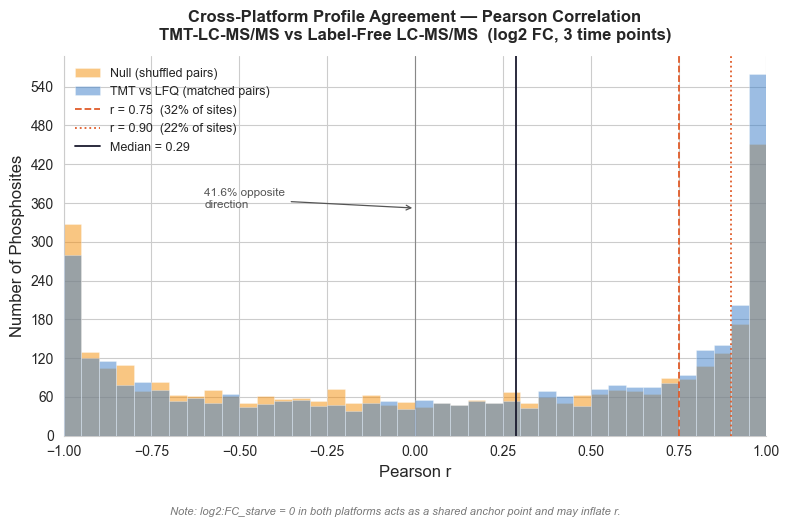

In [65]:
# =============================================================================
# PEARSON CORRELATION — one r value per phosphosite
# scipy.stats.pearsonr returns (r, p-value) per site
# =============================================================================

results = []
for site in common_sites:
    r, pval = stats.pearsonr(TMT_sub_df.loc[site], LFQ_sub_df.loc[site])
    results.append({"site": site, "pearson_r": r, "pval": pval})

results_df = pd.DataFrame(results).set_index("site")
# results_df.to_csv("pearson_correlations.csv")

pearson_r = results_df["pearson_r"].values

# Summary
print(f"\nPearson r summary:")
print(results_df["pearson_r"].describe().round(3))

p25, p50, p75 = np.percentile(pearson_r, [25, 50, 75])
pct_above_09  = np.mean(pearson_r >= 0.9)  * 100
pct_above_075 = np.mean(pearson_r >= 0.75) * 100
pct_below_0   = np.mean(pearson_r <  0.0)  * 100

print(f"\n  Median r               : {p50:.3f}")
print(f"  % sites r >= 0.90      : {pct_above_09:.1f}%")
print(f"  % sites r >= 0.75      : {pct_above_075:.1f}%")
print(f"  % sites r <  0.00      : {pct_below_0:.1f}%  (opposite direction)")

# =============================================================================
# NULL DISTRIBUTION — shuffle LFQ site pairing
# =============================================================================

rng = np.random.default_rng(seed=42)
n_sites      = len(common_sites)
shuffled_idx = rng.permutation(n_sites)
lfq_shuffled = LFQ_sub_df.values[shuffled_idx]

null_r = []
for i in range(n_sites):
    r_null, _ = stats.pearsonr(LFQ_sub_df.values[i], lfq_shuffled[i])
    null_r.append(r_null)
null_r = np.array(null_r)

# =============================================================================
# HISTOGRAM
# =============================================================================

fig, ax = plt.subplots(figsize=(8, 5))

bins = np.linspace(-1, 1, 41)   # fixed range for Pearson r

ax.hist(null_r, bins=bins, color="#f58e07", edgecolor="white", # color = "#d0d0d0"
        linewidth=0.4, alpha=0.5, label="Null (shuffled pairs)", zorder=2)

ax.hist(pearson_r, bins=bins, color="#3A7DC9", edgecolor="white",
        linewidth=0.4, alpha=0.5, label="TMT vs LFQ (matched pairs)", zorder=3)

# Reference lines
for thresh, label, ls in zip(
    [0.75, 0.90],
    ["r = 0.75", "r = 0.90"],
    ["--",       ":"]
):
    ax.axvline(thresh, color="#e05c2a", linestyle=ls, linewidth=1.3,
               label=f"{label}  ({np.mean(pearson_r >= thresh)*100:.0f}% of sites)", zorder=4)

# Median line
ax.axvline(p50, color="#1a1a2e", linestyle="-", linewidth=1.3,
           label=f"Median = {p50:.2f}", zorder=4)

# Opposite-direction annotation
if pct_below_0 > 0:
    ax.axvline(0, color="#888888", linestyle="-", linewidth=0.8, zorder=2)
    ax.annotate(f"{pct_below_0:.1f}% opposite\ndirection",
                xy=(0, ax.get_ylim()[1] * 0.6),
                xytext=(-0.6, ax.get_ylim()[1] * 0.6),
                fontsize=8.5, color="#555555",
                arrowprops=dict(arrowstyle="->", color="#555555", lw=0.9))

ax.set_xlabel("Pearson r", fontsize=12)
ax.set_ylabel("Number of Phosphosites", fontsize=12)
ax.set_xlim(-1, 1)
ax.set_title("Cross-Platform Profile Agreement — Pearson Correlation\n"
             "TMT-LC-MS/MS vs Label-Free LC-MS/MS  (log2 FC, 3 time points)",
             fontsize=12, fontweight="bold", pad=12)

ax.legend(frameon=False, fontsize=9, loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Caveat footnote
fig.text(0.5, -0.04,
         "Note: log2:FC_starve = 0 in both platforms acts as a shared anchor point and may inflate r.",
         ha="center", fontsize=8, color="#777777", style="italic")

plt.tight_layout()
# plt.savefig("pearson_correlation_histogram.png", dpi=150, bbox_inches="tight")
plt.show()
# print("Plot saved to pearson_correlation_histogram.png")


## Repeat similarity calculation on dataset where log2:FC > 0.5

### Filtration

In [66]:
LFQ = filter_dynamics_extremes_mutants(
    df = LFQ_dataset,
    data_type="log2:FC",
    threshold=0.5,
    exclude_full = True,
    conditions = ["_EGF_"],
    cell_lines = ["WT"],
)

mask = TMT_dataset[time_series].abs().max(axis=1) >= 0.5
TMT = TMT_dataset.loc[mask].copy()
print(LFQ.shape, TMT.shape)

(5514, 138) (4522, 482)


### Create column for both dataset with common name

In [67]:
TMT["new_site"] = TMT["site"].str.split("~").str[0]
TMT["new_site"] = (TMT["new_site"].str.split("_").str[0] + "_" + TMT["new_site"].str.split("_").str[-1])

LFQ["new_site"] = LFQ["site"].str.replace("_True", "").replace("_False", "")
LFQ["new_site"] = LFQ["new_site"].str.replace("_False", "")
LFQ["new_site"] = (LFQ["new_site"].str.split("_").str[0] + "_" + LFQ["new_site"].str.split("_").str[-1])

### Select time points to use and filter redundancy

In [68]:
columns = LFQ.columns
data_type = "log2:FC"
cell_line = ["WT"]
condition = ["_EGF_"]
times = [2, 10]

time_series = [element for element in columns if element.startswith(cell_line[0])
               and data_type in element
               and condition[0] in element
               ]
print(time_series)
time_series.remove("WT_log2:FC_EGF_25")
print(time_series)

['WT_log2:FC_EGF_starve', 'WT_log2:FC_EGF_2', 'WT_log2:FC_EGF_10', 'WT_log2:FC_EGF_25']
['WT_log2:FC_EGF_starve', 'WT_log2:FC_EGF_2', 'WT_log2:FC_EGF_10']


In [69]:
TMT_sites_list = list(TMT["new_site"].to_list())
LFQ_sites_list = list(LFQ["new_site"].to_list())

# Remove sites with more than one count (creates un-paring)
TMT_sites_1_count = [element for element in TMT_sites_list if TMT_sites_list.count(element) == 1]
LFQ_sites_1_count = [element for element in LFQ_sites_list if LFQ_sites_list.count(element) == 1]

common_sites = [site for site in TMT_sites_1_count if site in LFQ_sites_1_count]
print(len(common_sites))
print([common_sites[:10]])

264
[['A1L390_S1037', 'O00459_S263', 'O00515_S356', 'O14497_S363', 'O14686_S2274', 'O14950_T19S20', 'O15446_S136', 'O43399_S166', 'O43768_S67', 'O60271_T217']]


In [70]:
TMT.set_index("new_site", drop= False, inplace=True)
TMT_sub_df_05 = TMT.loc[TMT["new_site"].isin(common_sites)]
TMT_sub_df_05 = TMT_sub_df_05[time_series]

LFQ.set_index("new_site", drop = False,  inplace=True)
LFQ_sub_df_05 = LFQ.loc[LFQ["new_site"].isin(common_sites)]
LFQ_sub_df_05 = LFQ_sub_df_05[time_series]
print(TMT_sub_df_05.shape, LFQ_sub_df_05.shape)

TMT_sub_df_05.sort_index()
LFQ_sub_df_05.sort_index()

(264, 3) (264, 3)


,WT_log2:FC_EGF_starve,WT_log2:FC_EGF_2,WT_log2:FC_EGF_10
new_site,,,
A1L390_S1037,0.0,0.068571,0.698941
O00459_S263,0.0,0.654772,0.978787
O00515_S356,0.0,-0.218086,0.267980
O14497_S363,0.0,-0.218218,-0.521541
O14686_S2274,0.0,0.321471,1.545434
...,...,...,...
Q9Y6I3_S435,0.0,-0.106522,0.411811
Q9Y6I3_S454,0.0,-0.011135,0.995295
Q9Y6M7_T1167,0.0,-0.541672,-0.080299


### Calculate euclidean distances. Representation


Euclidean distance summary:
count    264.000
mean       0.721
std        0.642
min        0.023
25%        0.314
50%        0.525
75%        0.877
max        4.043
Name: euclidean_distance, dtype: float64

  25th percentile : 0.314
  50th percentile : 0.525
  75th percentile : 0.877
  90th percentile : 1.544


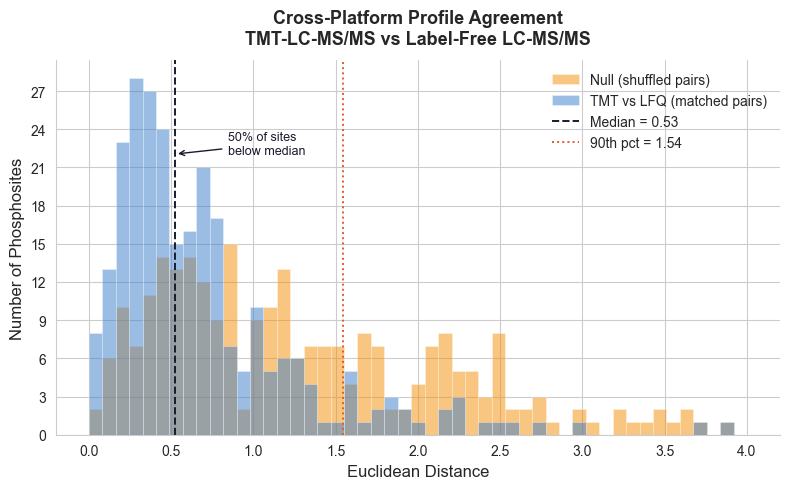

In [71]:
# calculate euclidena distances
diff = TMT_sub_df_05 - LFQ_sub_df_05
euclidean_distances = np.sqrt(np.sum(diff ** 2, axis=1))

distances = pd.Series(euclidean_distances, index=common_sites, name="euclidean_distance")

print(f"\nEuclidean distance summary:")
print(distances.describe().round(3))

# Percentile thresholds — useful for defining agreement categories later
p25, p50, p75, p90 = np.percentile(euclidean_distances, [25, 50, 75, 90])
print(f"\n  25th percentile : {p25:.3f}")
print(f"  50th percentile : {p50:.3f}")
print(f"  75th percentile : {p75:.3f}")
print(f"  90th percentile : {p90:.3f}")

# =============================================================================
# NULL DISTRIBUTION — distances from randomly shuffled site pairs
# =============================================================================
n_sites = len(common_sites)

rng = np.random.default_rng(seed=42)
n_permutations = n_sites                                 # same number as real distances

shuffled_idx = rng.permutation(n_sites)
# Pair each TMT profile with a random LFQ profile from a different site
lfq_shuffled = LFQ_sub_df_05.values[shuffled_idx]
diff_null = TMT_sub_df_05.values - lfq_shuffled
null_distances = np.sqrt(np.sum(diff_null ** 2, axis=1))
# =============================================================================
# HISTOGRAM
# =============================================================================

fig, ax = plt.subplots(figsize=(8, 5))

# Choose bin edges shared across both distributions for a fair visual comparison
all_values = np.concatenate([euclidean_distances, null_distances])
bins = np.linspace(0, np.percentile(all_values, 99), 50)

ax.hist(null_distances, bins=bins, color="#f58e07", edgecolor="white", # color = "#d0d0d0"
        linewidth=0.4, alpha=0.5, label="Null (shuffled pairs)", zorder=2)

ax.hist(euclidean_distances, bins=bins, color="#3A7DC9", edgecolor="white",
        linewidth=0.4, alpha=0.5, label="TMT vs LFQ (matched pairs)", zorder=3)

# Median line
ax.axvline(p50, color="#1a1a2e", linestyle="--", linewidth=1.4,
           label=f"Median = {p50:.2f}", zorder=4)

# 90th percentile line
ax.axvline(p90, color="#e05c2a", linestyle=":", linewidth=1.4,
           label=f"90th pct = {p90:.2f}", zorder=4)

# Labels and formatting
ax.set_xlabel("Euclidean Distance", fontsize=12)
ax.set_ylabel("Number of Phosphosites", fontsize=12)
ax.set_title("Cross-Platform Profile Agreement\nTMT-LC-MS/MS vs Label-Free LC-MS/MS",
             fontsize=13, fontweight="bold", pad=12)

ax.legend(frameon=False, fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Annotation: % of sites below median as a quick reproducibility read
pct_below_median = np.mean(euclidean_distances <= p50) * 100
ax.annotate(f"{pct_below_median:.0f}% of sites\nbelow median",
            xy=(p50, ax.get_ylim()[1] * 0.75),
            xytext=(p50 + (bins[-1] * 0.08), ax.get_ylim()[1] * 0.75),
            fontsize=9, color="#1a1a2e",
            arrowprops=dict(arrowstyle="->", color="#1a1a2e", lw=1.0))

plt.tight_layout()
# plt.savefig("euclidean_distance_histogram.png", dpi=150, bbox_inches="tight")
plt.show()
# print("\nPlot saved to euclidean_distance_histogram.png")

### Checking pearson correlation


Pearson r summary:
count    264.000
mean       0.712
std        0.566
min       -0.998
25%        0.856
50%        0.960
75%        0.992
max        1.000
Name: pearson_r, dtype: float64

  Median r               : 0.960
  % sites r >= 0.90      : 67.0%
  % sites r >= 0.75      : 80.3%
  % sites r <  0.00      : 12.5%  (opposite direction)


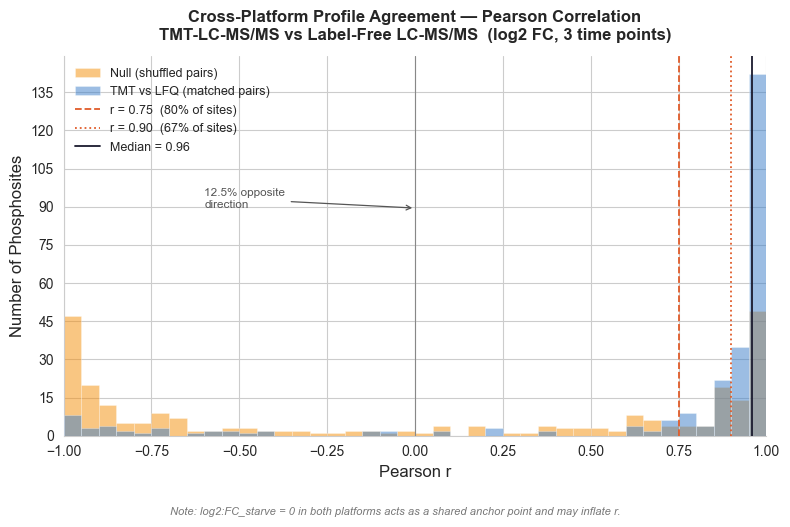

In [72]:
# =============================================================================
# PEARSON CORRELATION — one r value per phosphosite
# scipy.stats.pearsonr returns (r, p-value) per site
# =============================================================================

results = []
for site in common_sites:
    r, pval = stats.pearsonr(TMT_sub_df_05.loc[site], LFQ_sub_df_05.loc[site])
    results.append({"site": site, "pearson_r": r, "pval": pval})

results_df = pd.DataFrame(results).set_index("site")
# results_df.to_csv("pearson_correlations.csv")

pearson_r = results_df["pearson_r"].values

# Summary
print(f"\nPearson r summary:")
print(results_df["pearson_r"].describe().round(3))

p25, p50, p75 = np.percentile(pearson_r, [25, 50, 75])
pct_above_09  = np.mean(pearson_r >= 0.9)  * 100
pct_above_075 = np.mean(pearson_r >= 0.75) * 100
pct_below_0   = np.mean(pearson_r <  0.0)  * 100

print(f"\n  Median r               : {p50:.3f}")
print(f"  % sites r >= 0.90      : {pct_above_09:.1f}%")
print(f"  % sites r >= 0.75      : {pct_above_075:.1f}%")
print(f"  % sites r <  0.00      : {pct_below_0:.1f}%  (opposite direction)")

# =============================================================================
# NULL DISTRIBUTION — shuffle LFQ site pairing
# =============================================================================

rng = np.random.default_rng(seed=42)
n_sites      = len(common_sites)
shuffled_idx = rng.permutation(n_sites)
lfq_shuffled = LFQ_sub_df_05.values[shuffled_idx]

null_r = []
for i in range(n_sites):
    r_null, _ = stats.pearsonr(LFQ_sub_df_05.values[i], lfq_shuffled[i])
    null_r.append(r_null)
null_r = np.array(null_r)

# =============================================================================
# HISTOGRAM
# =============================================================================

fig, ax = plt.subplots(figsize=(8, 5))

bins = np.linspace(-1, 1, 41)   # fixed range for Pearson r

ax.hist(null_r, bins=bins, color="#f58e07", edgecolor="white", # color = "#d0d0d0"
        linewidth=0.4, alpha=0.5, label="Null (shuffled pairs)", zorder=2)

ax.hist(pearson_r, bins=bins, color="#3A7DC9", edgecolor="white",
        linewidth=0.4, alpha=0.5, label="TMT vs LFQ (matched pairs)", zorder=3)

# Reference lines
for thresh, label, ls in zip(
    [0.75, 0.90],
    ["r = 0.75", "r = 0.90"],
    ["--",       ":"]
):
    ax.axvline(thresh, color="#e05c2a", linestyle=ls, linewidth=1.3,
               label=f"{label}  ({np.mean(pearson_r >= thresh)*100:.0f}% of sites)", zorder=4)

# Median line
ax.axvline(p50, color="#1a1a2e", linestyle="-", linewidth=1.3,
           label=f"Median = {p50:.2f}", zorder=4)

# Opposite-direction annotation
if pct_below_0 > 0:
    ax.axvline(0, color="#888888", linestyle="-", linewidth=0.8, zorder=2)
    ax.annotate(f"{pct_below_0:.1f}% opposite\ndirection",
                xy=(0, ax.get_ylim()[1] * 0.6),
                xytext=(-0.6, ax.get_ylim()[1] * 0.6),
                fontsize=8.5, color="#555555",
                arrowprops=dict(arrowstyle="->", color="#555555", lw=0.9))

ax.set_xlabel("Pearson r", fontsize=12)
ax.set_ylabel("Number of Phosphosites", fontsize=12)
ax.set_xlim(-1, 1)
ax.set_title("Cross-Platform Profile Agreement — Pearson Correlation\n"
             "TMT-LC-MS/MS vs Label-Free LC-MS/MS  (log2 FC, 3 time points)",
             fontsize=12, fontweight="bold", pad=12)

ax.legend(frameon=False, fontsize=9, loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Caveat footnote
fig.text(0.5, -0.04,
         "Note: log2:FC_starve = 0 in both platforms acts as a shared anchor point and may inflate r.",
         ha="center", fontsize=8, color="#777777", style="italic")

plt.tight_layout()
# plt.savefig("pearson_correlation_histogram.png", dpi=150, bbox_inches="tight")
plt.show()
# print("Plot saved to pearson_correlation_histogram.png")


# Similarity with mutants

## Filtering mutans

In [56]:
LFQ_full = df_filtered.copy()

columns = LFQ_full.columns
data_type = "log2:FC"
cell_lines = ["WT", "BRAFS151A", "GAB1Y259A"]
conditions = ["_EGF_"]

columns_dir = {cell: {condition: {} for condition in conditions} for cell in cell_lines}

for cell in cell_lines:
    for condition in conditions:
        columns_dir[cell][condition] = [col for col in columns
                                        if col.startswith(cell)
                                        and data_type in col
                                        and condition in col
                                        ]
        print(columns_dir[cell][condition])
all_sites = [col for col in columns if data_type in col]

lfq_05_filter = filter_dynamics_extremes_mutants(
    df = LFQ_full,
    data_type="log2:FC",
    threshold=0.5, #0.5
    exclude_full = True,
    conditions = ["_EGF_"],
    cell_lines = cell_lines,
)
print(lfq_05_filter.shape)

common_sites = lfq_05_filter.site.unique()

lfq_05_filter.set_index("site", inplace=True, drop=False)
lfq_05_filter.sort_index()
lfq_wt = lfq_05_filter[columns_dir["WT"]["_EGF_"]]
lfq_braf = lfq_05_filter[columns_dir["BRAFS151A"]["_EGF_"]]
lfq_gab1 = lfq_05_filter[columns_dir["GAB1Y259A"]["_EGF_"]]

['WT_log2:FC_EGF_starve', 'WT_log2:FC_EGF_2', 'WT_log2:FC_EGF_10', 'WT_log2:FC_EGF_25']
['BRAFS151A_log2:FC_EGF_starve', 'BRAFS151A_log2:FC_EGF_2', 'BRAFS151A_log2:FC_EGF_10', 'BRAFS151A_log2:FC_EGF_25']
['GAB1Y259A_log2:FC_EGF_starve', 'GAB1Y259A_log2:FC_EGF_2', 'GAB1Y259A_log2:FC_EGF_10', 'GAB1Y259A_log2:FC_EGF_25']
(9561, 137)


## Pearson correlation LFQ

In [83]:
control = "WT"
test = "BRAF" # "BRAFS151A"  "GAB1Y259A"  "WT"

df_control = lfq_wt.copy()
df_test = lfq_braf.copy()

common_sites = lfq_05_filter.site.unique()


Pearson for BRAF r summary:
count    9561.000
mean       -0.135
std         0.576
min        -1.000
25%        -0.637
50%        -0.220
75%         0.338
max         1.000
Name: pearson_r, dtype: float64

  Median r               : -0.220
  % sites r >= 0.90      : 4.0%
  % sites r >= 0.75      : 9.5%
  % sites r <  0.00      : 60.7%  (opposite direction)


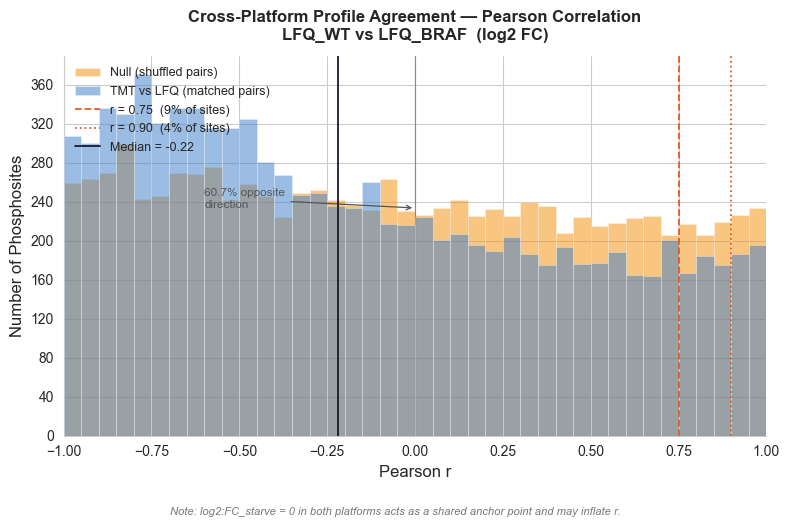

In [84]:
correlation_results = []

for site in common_sites:
    r, pval = stats.pearsonr(df_control.loc[site], df_test.loc[site])
    correlation_results.append({"site": site, "pearson_r": r, "pval": pval})


correlation_results = pd.DataFrame(correlation_results).set_index("site")

pearson_r = correlation_results["pearson_r"].values

# Summary
print(f"\nPearson for {test} r summary:")
print(correlation_results["pearson_r"].describe().round(3))

p25, p50, p75 = np.percentile(pearson_r, [25, 50, 75])
pct_above_09  = np.mean(pearson_r >= 0.9)  * 100
pct_above_075 = np.mean(pearson_r >= 0.75) * 100
pct_below_0   = np.mean(pearson_r <  0.0)  * 100

print(f"\n  Median r               : {p50:.3f}")
print(f"  % sites r >= 0.90      : {pct_above_09:.1f}%")
print(f"  % sites r >= 0.75      : {pct_above_075:.1f}%")
print(f"  % sites r <  0.00      : {pct_below_0:.1f}%  (opposite direction)")

# =============================================================================
# NULL DISTRIBUTION — shuffle LFQ site pairing
# =============================================================================

rng = np.random.default_rng(seed=42)
n_sites      = len(common_sites)
shuffled_idx = rng.permutation(n_sites)
df_shuffled = df_test.values[shuffled_idx]

null_r = []
for i in range(n_sites):
    # r_null, _ = stats.pearsonr(df_test.values[i], df_shuffled[i])
    r_null, _ = stats.pearsonr(df_control.values[i], df_shuffled[i])
    null_r.append(r_null)
null_r = np.array(null_r)

# =============================================================================
# HISTOGRAM
# =============================================================================

fig, ax = plt.subplots(figsize=(8, 5))

bins = np.linspace(-1, 1, 41)   # fixed range for Pearson r

ax.hist(null_r, bins=bins, color="#f58e07", edgecolor="white",  # color = "#f58e07" # #d0d0d0
        linewidth=0.4, alpha=0.5, label="Null (shuffled pairs)", zorder=2)

ax.hist(pearson_r, bins=bins, color="#3A7DC9", edgecolor="white",
        linewidth=0.4, alpha=0.5, label="TMT vs LFQ (matched pairs)", zorder=3)

# Reference lines
for thresh, label, ls in zip(
    [0.75, 0.90],
    ["r = 0.75", "r = 0.90"],
    ["--",       ":"]
):
    ax.axvline(thresh, color="#e05c2a", linestyle=ls, linewidth=1.3,
               label=f"{label}  ({np.mean(pearson_r >= thresh)*100:.0f}% of sites)", zorder=4)

# Median line
ax.axvline(p50, color="#1a1a2e", linestyle="-", linewidth=1.3,
           label=f"Median = {p50:.2f}", zorder=4)

# Opposite-direction annotation
if pct_below_0 > 0:
    ax.axvline(0, color="#888888", linestyle="-", linewidth=0.8, zorder=2)
    ax.annotate(f"{pct_below_0:.1f}% opposite\ndirection",
                xy=(0, ax.get_ylim()[1] * 0.6),
                xytext=(-0.6, ax.get_ylim()[1] * 0.6),
                fontsize=8.5, color="#555555",
                arrowprops=dict(arrowstyle="->", color="#555555", lw=0.9))

ax.set_xlabel("Pearson r", fontsize=12)
ax.set_ylabel("Number of Phosphosites", fontsize=12)
ax.set_xlim(-1, 1)
ax.set_title("Cross-Platform Profile Agreement — Pearson Correlation\n"
             f"LFQ_{control} vs LFQ_{test}  (log2 FC)",
             fontsize=12, fontweight="bold", pad=12)

ax.legend(frameon=False, fontsize=9, loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Caveat footnote
fig.text(0.5, -0.04,
         "Note: log2:FC_starve = 0 in both platforms acts as a shared anchor point and may inflate r.",
         ha="center", fontsize=8, color="#777777", style="italic")

plt.tight_layout()
# plt.savefig("pearson_correlation_histogram.png", dpi=150, bbox_inches="tight")
plt.savefig("Experiment/Progress_report/Images/pearson_correlation_histogram_WT_BRAF_new.pdf")

plt.show()
# print("Plot saved to pearson_correlation_histogram.png")


In [76]:
correlation_results

,pearson_r,pval
site,,
P19338_177_217_1_1_False_S206,0.487969,0.512031
P19338_177_217_2_1_False_S206M211,0.277420,0.722580
P19338_177_217_1_1_False_S184,-0.107665,0.892335
P19338_177_217_2_2_False_S206S184,0.575695,0.424305
P19338_177_217_3_2_True_S206M211S184,-0.428476,0.571524
...,...,...
P38159_2_9_1_0_False_N-term,-0.424462,0.575538
Q9UBE0_2_21_1_0_False_N-term,-0.905052,0.094948
P55735_2_27_1_0_False_N-term,0.924521,0.075479


## Euclidian distances

In [77]:
control = "WT"
test = "GAB1Y259A" # "BRAFS151A"  "GAB1Y259A"  "WT"

df_control = lfq_wt.copy()
df_test = lfq_gab1.copy()
print(f"Dataframes shapes: {df_control.shape}, {df_test.shape}")

common_sites = lfq_05_filter.site.unique()

Dataframes shapes: (6021, 4), (6021, 4)


In [78]:
# df_control = df_control[~df_control.index.duplicated(keep=False)]
# df_test = df_test[~df_test.index.duplicated(keep=False)]
# print(f"Dataframes shapes: {df_control.shape}, {df_test.shape}")



Euclidean distance summary between WT and GAB1Y259A:
count    6021.000
mean        1.488
std         1.334
min         0.025
25%         0.684
50%         1.147
75%         1.820
max        14.589
Name: euclidean_distance, dtype: float64

  25th percentile : 0.684
  50th percentile : 1.147
  75th percentile : 1.820
  90th percentile : 2.814


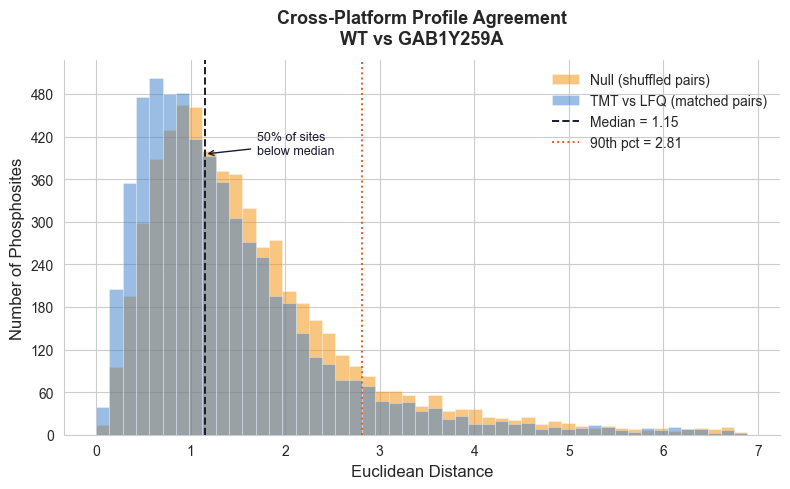

In [79]:
diff = df_control.values - df_test.values
euclidean_distances = np.sqrt(np.sum(diff ** 2, axis=1))

distances = pd.Series(euclidean_distances, index=common_sites, name="euclidean_distance")

print(f"\nEuclidean distance summary between {control} and {test}:")
print(distances.describe().round(3))

# Percentile thresholds — useful for defining agreement categories later
p25, p50, p75, p90 = np.percentile(euclidean_distances, [25, 50, 75, 90])
print(f"\n  25th percentile : {p25:.3f}")
print(f"  50th percentile : {p50:.3f}")
print(f"  75th percentile : {p75:.3f}")
print(f"  90th percentile : {p90:.3f}")

# =============================================================================
# NULL DISTRIBUTION — distances from randomly shuffled site pairs
# =============================================================================
n_sites = len(common_sites)

rng = np.random.default_rng(seed=42)
n_permutations = n_sites                                 # same number as real distances

shuffled_idx = rng.permutation(n_sites)
# Pair each TMT profile with a random LFQ profile from a different site
df_shuffled = df_test.values[shuffled_idx]
diff_null = df_control.values - df_shuffled
null_distances = np.sqrt(np.sum(diff_null ** 2, axis=1))
# =============================================================================
# HISTOGRAM
# =============================================================================

fig, ax = plt.subplots(figsize=(8, 5))

# Choose bin edges shared across both distributions for a fair visual comparison
all_values = np.concatenate([euclidean_distances, null_distances])
bins = np.linspace(0, np.percentile(all_values, 99), 50)

ax.hist(null_distances, bins=bins, color="#f58e07", edgecolor="white", # color = "#d0d0d0"
        linewidth=0.4, alpha=0.5, label="Null (shuffled pairs)", zorder=2)

ax.hist(euclidean_distances, bins=bins, color="#3A7DC9", edgecolor="white",
        linewidth=0.4, alpha=0.5, label="TMT vs LFQ (matched pairs)", zorder=3)

# Median line
ax.axvline(p50, color="#1a1a2e", linestyle="--", linewidth=1.4,
           label=f"Median = {p50:.2f}", zorder=4)

# 90th percentile line
ax.axvline(p90, color="#e05c2a", linestyle=":", linewidth=1.4,
           label=f"90th pct = {p90:.2f}", zorder=4)

# Labels and formatting
ax.set_xlabel("Euclidean Distance", fontsize=12)
ax.set_ylabel("Number of Phosphosites", fontsize=12)
ax.set_title(f"Cross-Platform Profile Agreement\n{control} vs {test}",
             fontsize=13, fontweight="bold", pad=12)

ax.legend(frameon=False, fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Annotation: % of sites below median as a quick reproducibility read
pct_below_median = np.mean(euclidean_distances <= p50) * 100
ax.annotate(f"{pct_below_median:.0f}% of sites\nbelow median",
            xy=(p50, ax.get_ylim()[1] * 0.75),
            xytext=(p50 + (bins[-1] * 0.08), ax.get_ylim()[1] * 0.75),
            fontsize=9, color="#1a1a2e",
            arrowprops=dict(arrowstyle="->", color="#1a1a2e", lw=1.0))

plt.tight_layout()
# plt.savefig("euclidean_distance_histogram.png", dpi=150, bbox_inches="tight")
plt.show()
# print("\nPlot saved to euclidean_distance_histogram.png")